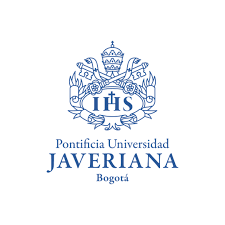

## *** Proyecto final Computación de Alto Desempeño***
## **Implementación modelos para verificar pureza y calidad del agua**


Autor: Juan Camilo Torres
Fecha actual: 27 de mayo de 2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.

## **Metodología**

1. Importación de bibliotecas y levantamiento de sesión Spark sobre el clúster HPC.
2. Carga de datos desde el HDFS del clúster (`hdfs://10.195.34.34:9000/csv/waterquality.csv`).
3. Preprocesamiento: cambio de tipos, análisis de nulos, filtrado y limpieza con PySpark SQL.
4. Análisis Exploratorio de Datos (EDA) y visualización de parámetros.
5. Cálculo del Índice WQI y clasificación de la calidad del agua.
6. Visualización geoespacial sobre el mapa de la India (GeoPandas).
7. Entrenamiento de cuatro modelos: Red Neuronal Keras, MLlib Random Forest, MLlib Gradient Boosted Trees (modelo adicional) y MLlib Regresión Lineal (baseline).
8. Evaluación y comparación con `RegressionEvaluator` de PySpark MLlib.
9. Análisis.
10. conclusiones.

**Referencia de calidad de parámetros del agua:** https://www.intechopen.com/chapters/69568



### Importación de librerías para la implementación

In [112]:
# Levantamiento de variables de entorno pip
import os
import sys
sys.path.append('/usr/lib/python3/dist-packages/')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *
import findspark
findspark.init()
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *



### Crear sesión de spark

In [113]:
### Levantamiento de sesión SPARK
configura = SparkConf()
configura.setAppName("Calidad_Agua_Torres ")
sparkS = SparkSession.builder.config(conf=configura).getOrCreate()
SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)
sparkContextoS = sparkS.sparkContext.getOrCreate()
print("Sesion creada: Calidad_Agua_Torres")


Sesion creada: Calidad_Agua_Torres


### Carga de datos desde Hadoop HDFS

In [114]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkS.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")
print(f'Cantidad de registros: {df00.count()}')

df00.show(5)

Found 11 items
-rw-r--r--   2 sistemas supergroup     977501 2026-03-10 15:27 /csv/CustomerChurn.csv
-rw-r--r--   2 sistemas supergroup      40868 2025-07-07 15:41 /csv/Fortune500USCompanies.csv
drwxr-xr-x   - sistemas supergroup          0 2025-10-16 14:17 /csv/auxiliar
-rw-r--r--   2 sistemas supergroup    4610348 2026-04-28 08:17 /csv/bank-full.csv
-rw-r--r--   2 sistemas supergroup      34635 2025-09-02 13:22 /csv/jugadores.csv
-rw-r--r--   2 sistemas supergroup    1082023 2025-09-02 13:22 /csv/resultados_futbol.csv
-rw-r--r--   2 sistemas supergroup     316971 2025-06-10 09:11 /csv/stroke_pyspark.csv
drwxr-xr-x   - sistemas supergroup          0 2025-06-18 15:36 /csv/taxi
drwxr-xr-x   - sistemas supergroup          0 2026-04-23 15:56 /csv/titanic
-rw-r--r--   2 sistemas supergroup      48036 2025-06-12 14:31 /csv/waterquality.csv
-rw-r--r--   2 sistemas supergroup      84199 2026-04-23 17:11 /csv/winequality-red.csv
Cantidad de registros: 534
+------------+--------------------+---

### Análisis y preparación de datos ETL

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

#### Columnas de los datos crudos

In [115]:
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

#### Descripción de cada columnna
- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

#### Distribución de los datos

In [116]:
for valor in df00.columns:
  df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               null|
| stddev|               null|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          null|
| stddev|          null|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+---------

#### Histograma de datos

Se visualiza la distribución de datos por cada columna para cada clase

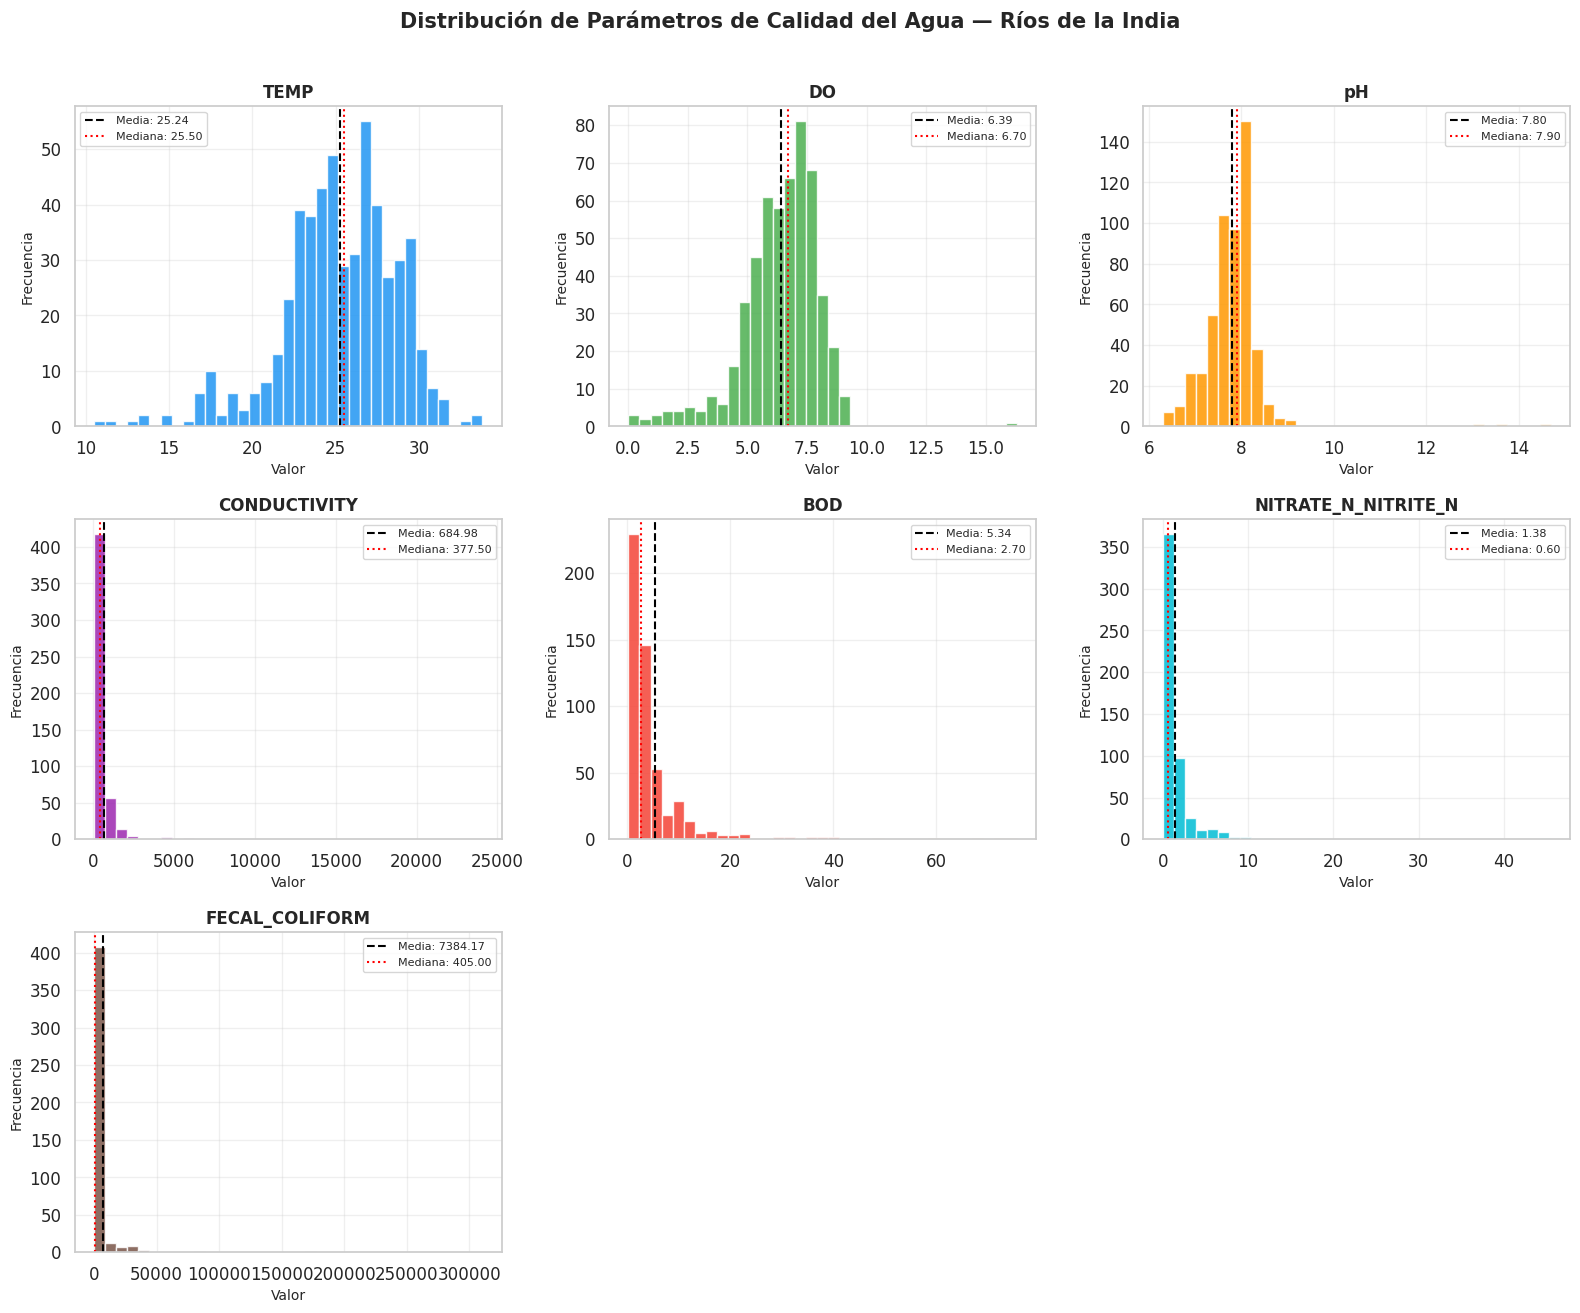

In [117]:
df_pandas = df00.select(
    "TEMP", "DO", "pH", "CONDUCTIVITY",
    "BOD", "NITRATE_N_NITRITE_N", "FECAL_COLIFORM"
).toPandas()

for col in df_pandas.columns:
    df_pandas[col] = pd.to_numeric(df_pandas[col], errors='coerce')

palette = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4', '#795548']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
columnas = df_pandas.columns.tolist()

for i, col in enumerate(columnas):
    data = df_pandas[col].dropna()
    axes[i].hist(data, bins=35, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Media: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='red', linestyle=':', linewidth=1.5,
                    label=f'Mediana: {data.median():.2f}')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

for j in range(len(columnas), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribución de Parámetros de Calidad del Agua — Ríos de la India',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretación de los Histogramas de Parámetros

Cada histograma muestra la frecuencia de los valores medidos en las estaciones de monitoreo de ríos de la India. Las líneas **negra punteada** (media) y **roja punteada** (mediana) permiten identificar simetría y la influencia de valores extremos.

#### Variables con distribución aproximadamente normal
- **TEMP** — Temperatura concentrada entre 20–30 °C, con pico alrededor de 25 °C. La cercanía entre media y mediana indica distribución simétrica, típica de promedios estacionales.
- **DO (Oxígeno Disuelto)** — Concentrado entre 6–9 mg/L con forma de campana. La mayoría de los ríos tienen niveles aceptables de oxígeno para la vida acuática (umbral mínimo: 6 mg/L).
- **pH** — Mayoría de valores entre 7–9, con pico en ~8. Aguas mayormente neutras a ligeramente alcalinas, rango normal para ecosistemas fluviales.

#### Variables con distribución sesgada a la derecha (presencia de outliers)
- **CONDUCTIVITY** — El 90%+ de datos se acumula en 0–2000 µS/cm, pero hay valores extremos hasta ~25 000 µS/cm. Indica que la mayoría de los ríos son de baja mineralización, pero algunos presentan contaminación salina o industrial severa.
- **BOD (Demanda Biológica de Oxígeno)** — La mayoría de ríos tiene BOD < 10 mg/L, con outliers hasta 75 mg/L. El sesgo hacia la derecha revela focos puntuales de contaminación orgánica intensa.
- **NITRATE_N_NITRITE_N** — Concentrado en 0–5 mg/L con cola larga. Los valores altos de nitratos son indicativos de escorrentía agrícola con fertilizantes nitrogenados.
- **FECAL_COLIFORM** — El caso más extremo: la mayor parte de valores están próximos a cero, pero existen outliers que alcanzan 300 000 MPN/100 ml. Esta distribución altamente sesgada indica contaminación fecal crítica en puntos específicos, que representan un grave riesgo sanitario.

#### Validación de Datos Nulos

In [118]:
#Cantidad de Valores Nulos o Imposibles

df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



*No se encuentra ningún valor nulo ni imposible basado en la salida del comando anterior*

* Se procede a Graficar cada una de las dimensiones
* Se crea una vista para ser usada en las visualizaciones

In [119]:

df00.createOrReplaceTempView("df00_sql")
df01 = sparkS.sql('''Select * from df00_sql where TEMP is not null and
     DO is not null and
     pH is not null and
     CONDUCTIVITY is not null and
     BOD is not null and
     NITRATE_N_NITRITE_N is not null and
     FECAL_COLIFORM is not null''')

En PySpark, al igual que en motores de bases de datos relacionales como PostgreSQL o MySQL, es posible crear vistas temporales sobre un DataFrame para consultarlo usando sintaxis SQL estándar.

Esta instrucción registra el DataFrame df00 como una vista temporal llamada df00_sql dentro de la sesión Spark activa. La vista no almacena datos físicamente — es simplemente una referencia nombrada al DataFrame original, análoga a una VIEW en SQL tradicional. Al ser temporal, existe únicamente durante la sesión Spark y se elimina automáticamente al finalizarla.

Se verifica la Cantidad de Valores Nulos o Imposibles


df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

Aunque para este caso la eliminnación de datos nulos e imposibles, no tiene ningún efecto porque no existía ninguno inicialmente, se deja como parte del pipeline en caso de que los datos cambien en un futuro y se requiera hacer nuevamente un proceso de etl que si implique algún campo inválido.

### Tratamiento de Datos

Se procede a cambiar los tipos de datos

In [120]:
df00.dtypes

df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'float'),
 ('DO', 'float'),
 ('pH', 'float'),
 ('CONDUCTIVITY', 'float'),
 ('BOD', 'float'),
 ('NITRATE_N_NITRITE_N', 'float'),
 ('FECAL_COLIFORM', 'float'),
 ('TOTAL_COLIFORM', 'string')]

Se elimina la columna TOTAL_COLIFORM

In [121]:
df01 = df00.drop('TOTAL_COLIFORM')
df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

###  Creación de Tablas para Visualizar los Datos

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

In [122]:
df01.createOrReplaceTempView("df01_sql")

columnas = ["DO", "pH", "CONDUCTIVITY", "BOD", "NITRATE_N_NITRITE_N", "FECAL_COLIFORM"]

###Se crea una consulta por cada parámetro DO
parametros = {}
for col in columnas:
    ##Se hace una consulta para crear el vector de la tabla por cada parámetro
    parametros[col] = sparkS.sql(f"SELECT {col} FROM df01_sql") \
                            .rdd.map(lambda fila, c=col: getattr(fila, c)) \
                            .collect()

In [123]:
parametros["DO"]
parametros["pH"]
parametros["CONDUCTIVITY"]
parametros["BOD"]
parametros["NITRATE_N_NITRITE_N"]
parametros["FECAL_COLIFORM"]

[3.0,
 72.0,
 59.0,
 90.0,
 45.0,
 131.0,
 122.0,
 110.0,
 77.0,
 22.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 3.0,
 2.0,
 27.0,
 130.0,
 240.0,
 500.0,
 130.0,
 300.0,
 300.0,
 280.0,
 240.0,
 2.0,
 3.0,
 2.0,
 48.0,
 None,
 3.0,
 23.0,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 664.0,
 4000.0,
 370.0,
 410.0,
 400.0,
 2200.0,
 2978.0,
 2333.0,
 2600.0,
 15889.0,
 5517.0,
 5158.0,
 17283.0,
 18333.0,
 19500.0,
 1567.0,
 2146.0,
 2617.0,
 31167.0,
 17500.0,
 70.0,
 1190.0,
 3183.0,
 1600.0,
 660.0,
 1483.0,
 6527.0,
 3782.0,
 1382.0,
 1846.0,
 1251.0,
 2792.0,
 1622.0,
 1560.0,
 2933.0,
 2678.0,
 1705.0,
 1198.0,
 1106.0,
 998.0,
 1220.0,
 1290.0,
 1846.0,
 1048.0,
 166358.0,
 143275.0,
 34392.0,
 106417.0,
 153917.0,
 285833.0,
 122417.0,
 310417.0,
 31417.0,
 41750.0,
 146.0,
 2128.0,
 585.0,
 12418.0,
 5449.0,
 444.0,
 3388.0,
 1653.0,
 1208.0,
 2990.0,
 15.0,
 None,
 149.0,
 2.0,
 None,
 4.0,
 183.0,
 191.0,
 171.0,
 780.0,
 890.0,
 518.0,
 792.0,
 538.0,
 678.0

### Grafica Los parámetros para conocer sus características: DO y PH

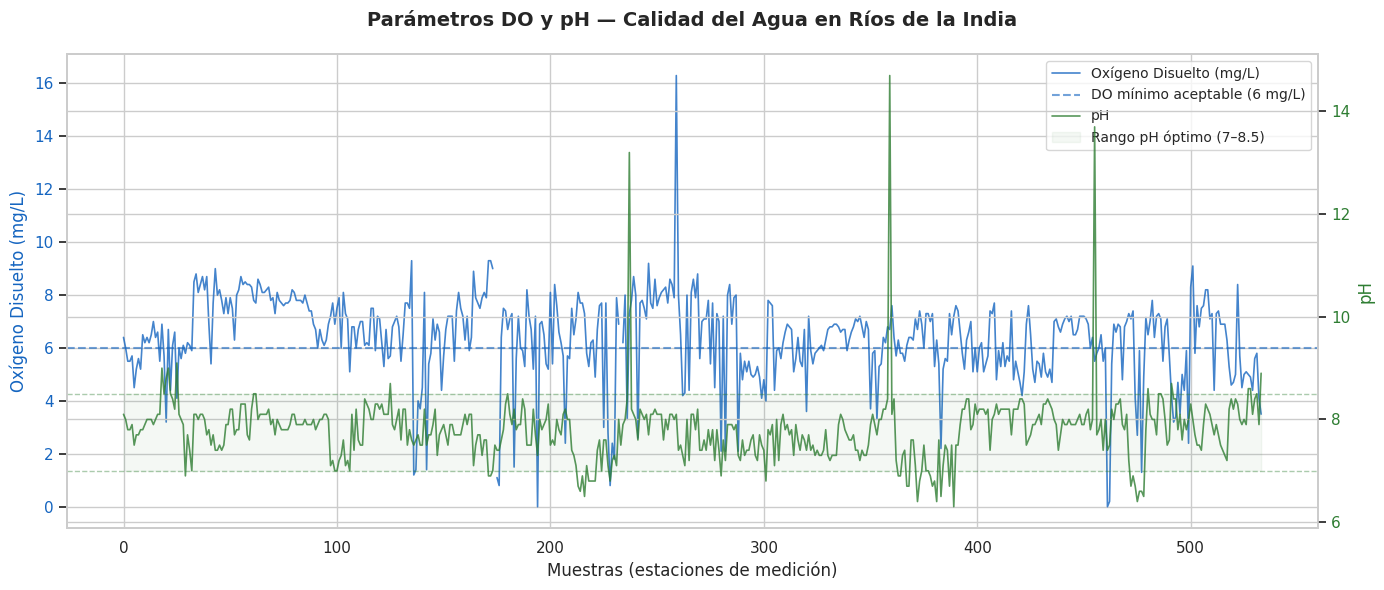

In [124]:
sns.set_style("whitegrid")
sns.set_context("notebook")

tam = len(parametros["DO"])
fig, ax1 = plt.subplots(figsize=(14, 6))

color_do = '#1565C0'
ax1.plot(range(tam), parametros["DO"], color=color_do, linewidth=1.2,
         alpha=0.8, label='Oxígeno Disuelto (mg/L)')
ax1.axhline(y=6.0, color=color_do, linestyle='--', linewidth=1.5,
            alpha=0.6, label='DO mínimo aceptable (6 mg/L)')
ax1.set_xlabel('Muestras (estaciones de medición)', fontsize=12)
ax1.set_ylabel('Oxígeno Disuelto (mg/L)', color=color_do, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_do)

ax2 = ax1.twinx()
color_ph = '#2E7D32'
x_range = range(tam)
ax2.plot(range(tam), parametros["pH"], color=color_ph, linewidth=1.2,
         alpha=0.8, label='pH')
ax2.axhline(y=7.0, color=color_ph, linestyle='--', linewidth=1, alpha=0.4)
ax2.axhline(y=8.5, color=color_ph, linestyle='--', linewidth=1, alpha=0.4)
ax2.fill_between(range(tam), 7, 8.5, alpha=0.05, color=color_ph,
                 label='Rango pH óptimo (7–8.5)')
ax2.set_ylabel('pH', color=color_ph, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_ph)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

fig.suptitle('Parámetros DO y pH — Calidad del Agua en Ríos de la India',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación: Oxígeno Disuelto (DO) y pH

- **DO (Oxígeno Disuelto):** El umbral mínimo de **6 mg/L** es el límite aceptable para sostener vida acuática (peces, macroinvertebrados). Las muestras por debajo de este umbral indican estrés para el ecosistema. Los valles en la curva pueden correlacionarse con zonas de alta contaminación orgánica (alta DBO consume el oxígeno disponible).
- **pH:** El rango óptimo de **7.0 a 8.5** (sombreado verde) corresponde a condiciones neutras a ligeramente alcalinas, propias de ecosistemas fluviales saludables. Valores inferiores a 6.5 indican acidificación (lluvias ácidas o minería); superiores a 9 señalan contaminación alcalina o eutrofización severa por algas.
- **Relación entre variables:** El DO y el pH presentan cierta correlación positiva: en aguas más alcalinas (pH alto) la fotosíntesis de algas produce oxígeno, mientras que en aguas contaminadas ambas variables tienden a deteriorarse simultáneamente.
- **Ejes independientes:** Se usan ejes Y separados (izquierdo para DO, derecho para pH) ya que las unidades y escalas difieren.

### Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

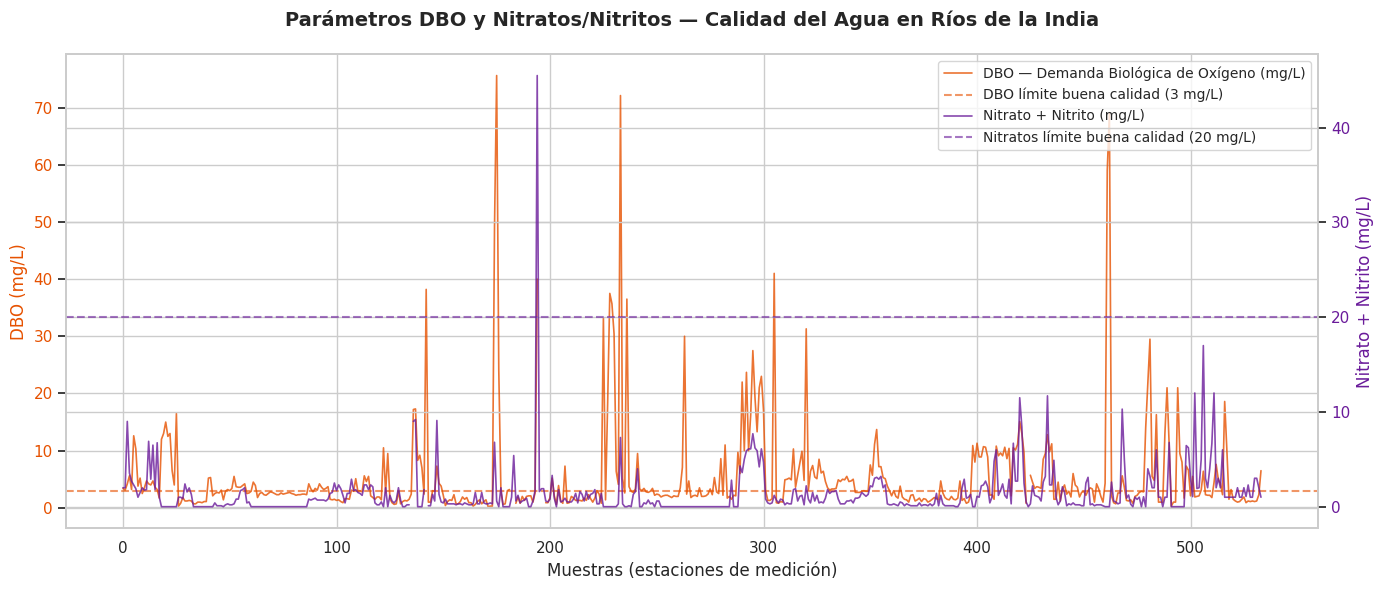

In [125]:
sns.set_style("whitegrid")

tam = len(parametros["BOD"])
fig, ax1 = plt.subplots(figsize=(14, 6))

color_bod = '#E65100'
ax1.plot(range(tam), parametros["BOD"], color=color_bod, linewidth=1.2,
         alpha=0.8, label='DBO — Demanda Biológica de Oxígeno (mg/L)')
ax1.axhline(y=3.0, color=color_bod, linestyle='--', linewidth=1.5,
            alpha=0.6, label='DBO límite buena calidad (3 mg/L)')
ax1.set_xlabel('Muestras (estaciones de medición)', fontsize=12)
ax1.set_ylabel('DBO (mg/L)', color=color_bod, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_bod)

ax2 = ax1.twinx()
color_nn = '#6A1B9A'
ax2.plot(range(tam), parametros["NITRATE_N_NITRITE_N"], color=color_nn,
         linewidth=1.2, alpha=0.8, label='Nitrato + Nitrito (mg/L)')
ax2.axhline(y=20.0, color=color_nn, linestyle='--', linewidth=1.5,
            alpha=0.6, label='Nitratos límite buena calidad (20 mg/L)')
ax2.set_ylabel('Nitrato + Nitrito (mg/L)', color=color_nn, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_nn)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

fig.suptitle('Parámetros DBO y Nitratos/Nitritos — Calidad del Agua en Ríos de la India',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación: DBO (Demanda Biológica de Oxígeno) y Nitratos/Nitritos

- **DBO:** Mide la cantidad de oxígeno que los microorganismos consumen al descomponer materia orgánica. Valores por encima de **3 mg/L** indican contaminación orgánica moderada; por encima de **6 mg/L** la contaminación es severa. Los picos corresponden a puntos de descarga industrial o agrícola con alta carga orgánica.
- **Nitratos + Nitritos:** Nutrientes inorgánicos nitrogenados cuyo exceso provoca **eutrofización**: proliferación de algas, reducción de oxígeno disuelto y pérdida de biodiversidad. Concentraciones por encima de **20 mg/L** señalan contaminación moderada, generalmente asociada a escorrentía agrícola con fertilizantes nitrogenados o descarga de aguas residuales urbanas.
- **Escalas independientes:** Ambas variables se grafican en ejes Y separados para permitir la visualización simultánea de sus fluctuaciones, independientemente de las diferencias en su rango de valores.

### Grafica Los parámetros para conocer sus características: FC y Conductividad

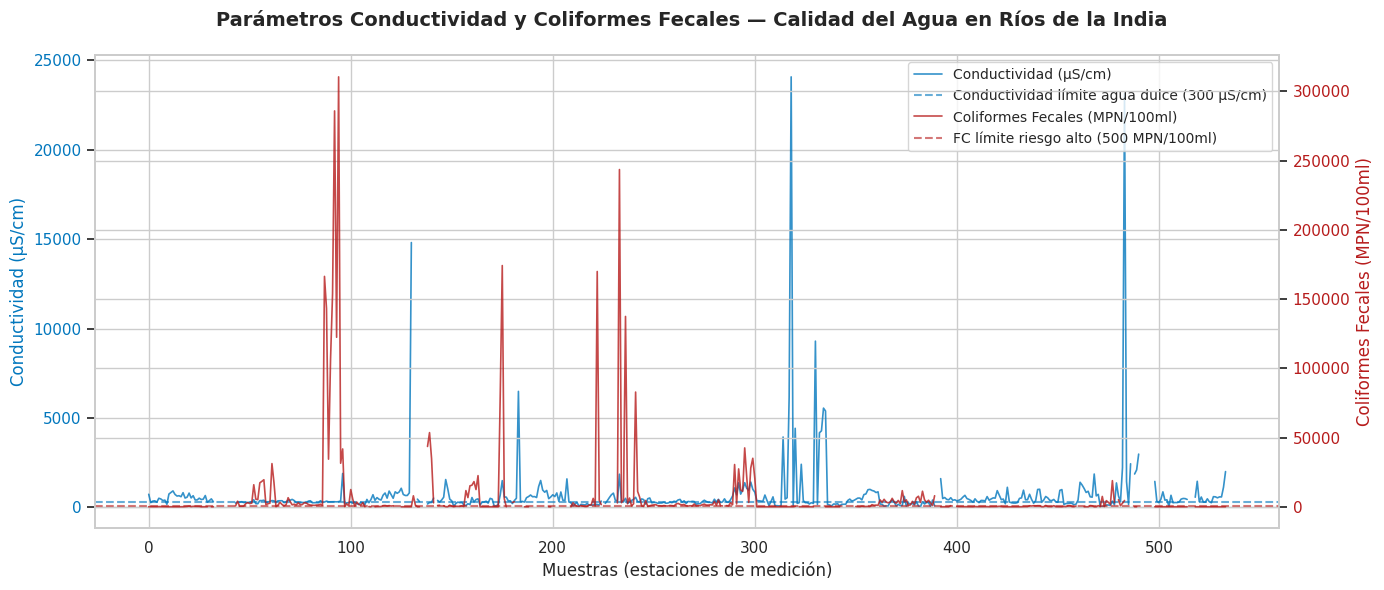

In [126]:
sns.set_style("whitegrid")

tam = len(parametros["CONDUCTIVITY"])
fig, ax1 = plt.subplots(figsize=(14, 6))

color_cond = '#0277BD'
ax1.plot(range(tam), parametros["CONDUCTIVITY"], color=color_cond,
         linewidth=1.2, alpha=0.8, label='Conductividad (µS/cm)')
ax1.axhline(y=300.0, color=color_cond, linestyle='--', linewidth=1.5,
            alpha=0.6, label='Conductividad límite agua dulce (300 µS/cm)')
ax1.set_xlabel('Muestras (estaciones de medición)', fontsize=12)
ax1.set_ylabel('Conductividad (µS/cm)', color=color_cond, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_cond)

ax2 = ax1.twinx()
color_fc = '#B71C1C'
ax2.plot(range(tam), parametros["FECAL_COLIFORM"], color=color_fc,
         linewidth=1.2, alpha=0.8, label='Coliformes Fecales (MPN/100ml)')
ax2.axhline(y=500.0, color=color_fc, linestyle='--', linewidth=1.5,
            alpha=0.6, label='FC límite riesgo alto (500 MPN/100ml)')
ax2.set_ylabel('Coliformes Fecales (MPN/100ml)', color=color_fc, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_fc)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

fig.suptitle('Parámetros Conductividad y Coliformes Fecales — Calidad del Agua en Ríos de la India',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación: Conductividad y Coliformes Fecales

- **Conductividad:** Mide la capacidad del agua para conducir electricidad, indicando la presencia de sales e iones disueltos. Valores por encima de **300 µS/cm** pueden señalar mineralización excesiva, contaminación industrial o intrusión salina. Conductividades muy elevadas pueden ser tóxicas para organismos acuáticos sensibles.
- **Coliformes Fecales:** Son el indicador microbiológico más directo de contaminación fecal (humana o animal). Los picos extremos (miles o decenas de miles de MPN/100 ml) representan un **riesgo sanitario grave** e indican descarga directa de aguas residuales sin tratar a los ríos. El umbral de riesgo alto está establecido en **500 MPN/100 ml** para cuerpos de agua recreativos.
- **Escalas independientes:** Dado que la conductividad y los coliformes fecales operan en magnitudes muy diferentes (µS/cm vs. MPN/100 ml), se utilizan ejes Y independientes (izquierdo y derecho) para que ambas variables sean legibles en la misma gráfica sin compresión visual.

### Función definida por el usuario para definir el rango de calidad de agua según el pH
*Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)*

In [127]:
df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).
    when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).
    when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).
    when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

### Función definida por el usuario para definir el rando de la calidad del agua según DO

In [128]:
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
     when((df01.DO>=5.1) & (df01.DO<6.0), 80).
     when((df01.DO>=4.1) & (df01.DO<5.0), 60).
     when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

### Función definida por el usuario para definir el rando de la calidad del agua según COND

In [129]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
    when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
    when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
    when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

### Función definida por el usuario para definir el rando de la calidad del agua según BOD

In [130]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
    when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
    when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
    when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N
    * 100: Agua Dulce
    *  80: Agua Moderada
    *  60: Agua Dura
    *  40: Agua muy Dura

In [131]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                      when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                      when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                      when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  100: Agua Dulce
  *   80: Agua Moderada
  *   60: Agua Dura
  *   40: Agua muy Dura

In [132]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
                      when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
                      when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
                      when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

### Inspeccionar los datos en df02

##**El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**


In [133]:
#A continuación se hace una inspección en general del df02
df02.show(10)
##Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

### **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

#### Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [134]:

df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))
df03.show(10)
df03.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

## **Calculo del Índice de Calidad del Agua**


   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

In [135]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

In [136]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
    .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
    .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
    .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
    .otherwise('Inadecuada')
                      )
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

- #Impresión de nombre de regiones sobre el mapa


In [139]:
colEstado = 'STATE'
valNomnbres = df05.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**

Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

In [140]:
import geopandas as gpd

rutaMapas = "Indian_States.shp"
## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)
## Se visualiza el tipo de dataframe que da geopandas y las columnas 

print(type(gpd01))

gpd01.columns


#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
### con los nombres de los estados del dataframe de datos inicial

gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                       'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                      'Daman & Diu': 'Daman Diu', 
                       'Jammu & Kashmir': 'Jammu Kashmir',
                       'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
nombre de "st_nm" que sea "STATE"
Se combinan es formato pandas para pintar el mapa
Se garantizan los puntos dentro del mapa
Se eliminan los duplicados

In [141]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [142]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

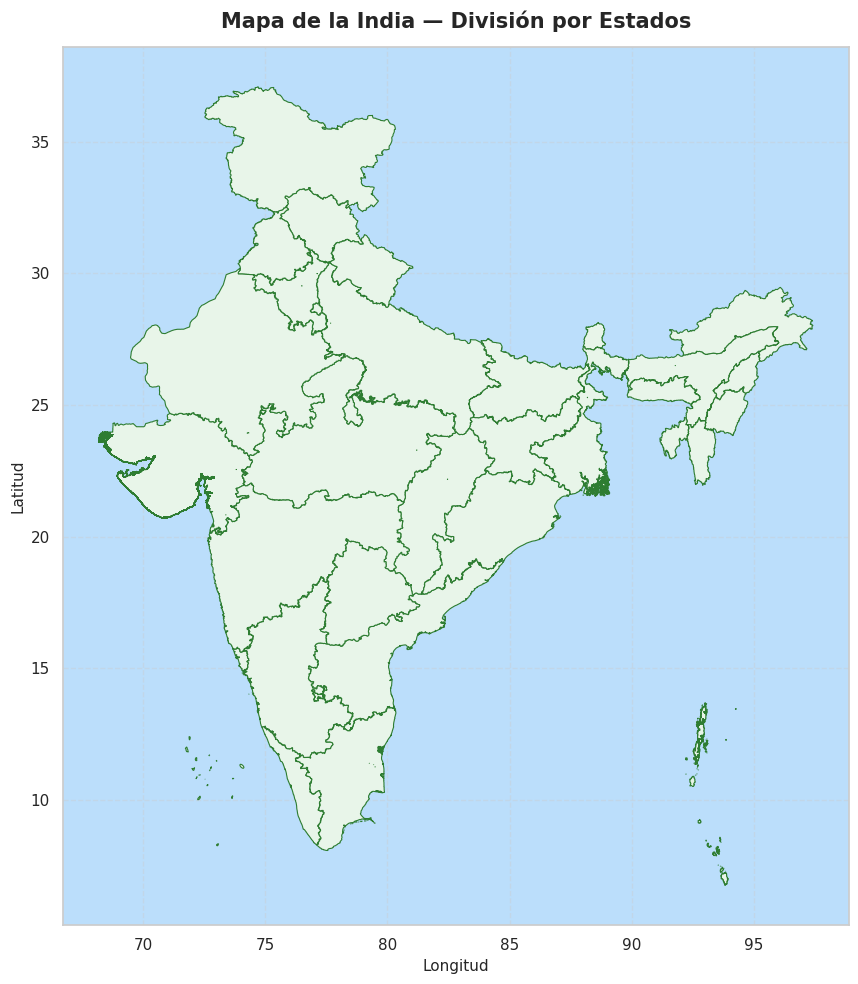

In [143]:
fig, ax = plt.subplots(figsize=(12, 10))
dfMAP.plot(color='#E8F5E9', edgecolor='#2E7D32', linewidth=0.8, ax=ax,
           missing_kwds={'color': '#EEEEEE', 'label': 'Sin datos'})
ax.set_title('Mapa de la India — División por Estados', fontsize=15,
             fontweight='bold', pad=14)
ax.set_xlabel('Longitud', fontsize=11)
ax.set_ylabel('Latitud', fontsize=11)
ax.set_facecolor('#BBDEFB')
ax.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

#### Interpretación: Mapa Geográfico Inicial de la India

Este mapa muestra la división político-administrativa de la India por estados y territorios de unión. El fondo azul representa cuerpos de agua circundantes, mientras que el relleno verde claro con bordes oscuros facilita la diferenciación entre estados.

- **Cobertura geográfica:** El dataset abarca la mayor parte del territorio indio: estados del norte (Uttar Pradesh, Bihar), el sur (Tamil Nadu, Kerala, Karnataka), las zonas costeras del este y del oeste, y los estados del noreste.
- **Propósito:** Este mapa inicial sirve como referencia geográfica base. Las visualizaciones posteriores superpondrán el Índice de Calidad del Agua (WQI) sobre esta misma estructura espacial.
- **Contexto hídrico:** India cuenta con una extensa red fluvial que incluye los ríos Ganges, Brahmaputra, Krishna, Godavari, Cauvery y Narmada, entre los principales. La calidad varía significativamente según densidad poblacional, actividad industrial y prácticas agrícolas de cada cuenca.

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [144]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


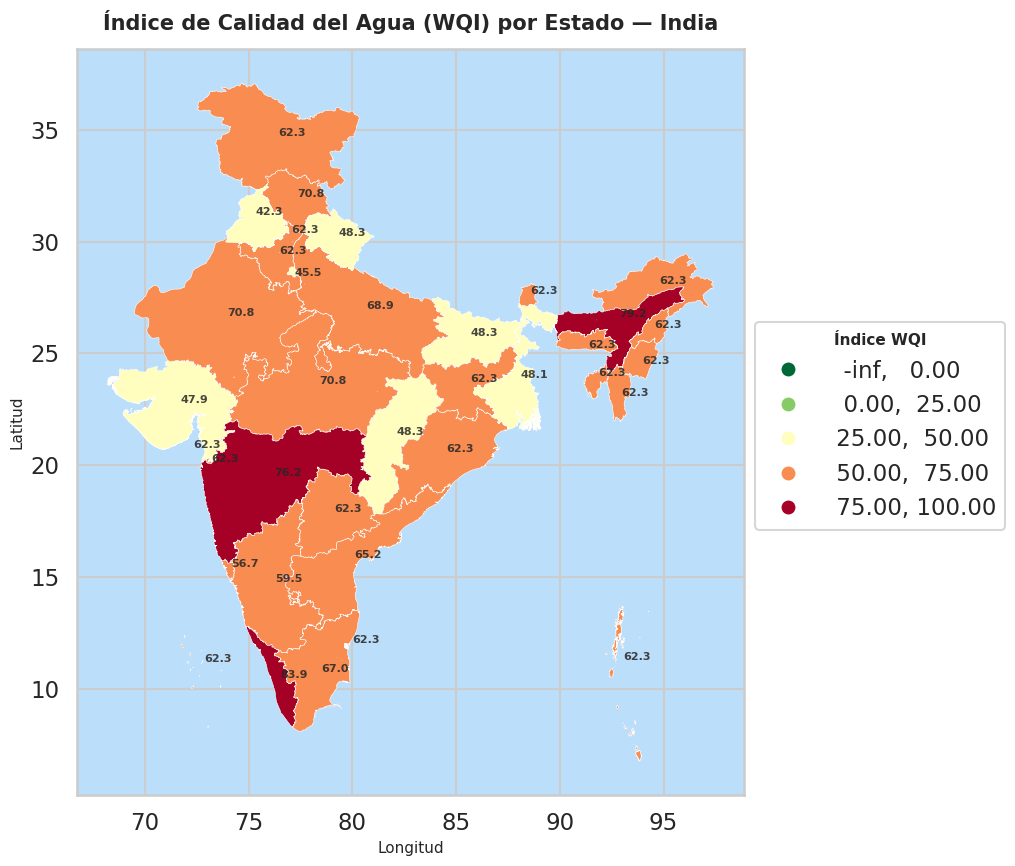

In [145]:
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

sns.set_context("talk")
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(13, 9))
ax.set_facecolor('#BBDEFB')

dfMAP.plot(column='WQI', cmap='RdYlGn_r', ax=ax, scheme='userdefined',
           classification_kwds={'bins': [0, 25, 50, 75, 100]},
           legend=True, linewidth=0.4, edgecolor='white')

leg = ax.get_legend()
leg.set_title('Índice WQI', prop={'size': 11, 'weight': 'bold'})
leg.set_bbox_to_anchor((1.0, 0.65))

textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.1f}",
                            xy=(centroide.x, centroide.y),
                            fontsize=8, alpha=0.85,
                            fontweight='bold')
        textos.append(texto)

adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

ax.set_title('Índice de Calidad del Agua (WQI) por Estado — India',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Longitud', fontsize=11)
ax.set_ylabel('Latitud', fontsize=11)
plt.tight_layout()
plt.show()

#### Interpretación: Mapa del Índice de Calidad del Agua (WQI) por Estado

- **Escala de color (RdYlGn_r):** Los colores más rojos indican WQI más alto y, por ende, **peor calidad del agua**. Los tonos verdes señalan mejor calidad relativa. El esquema de clasificación divide el índice en cuatro rangos: 0–25 (Excelente), 25–50 (Buena), 50–75 (Baja) y 75–100 (Muy Baja).
- **Distribución geográfica:** Los estados con mayor actividad industrial y densidad poblacional, especialmente en la cuenca del Ganges (norte de la India), tienden a presentar valores WQI más elevados.
- **Anotaciones numéricas:** El valor WQI promedio de cada estado está superpuesto sobre el mapa para facilitar la comparación directa entre regiones sin necesidad de consultar la leyenda.
- **Estados sin datos:** Las regiones en gris claro no cuentan con estaciones de monitoreo en el dataset, lo que puede sesgar la interpretación geográfica total.

### **Histograma de WQI por Estado**

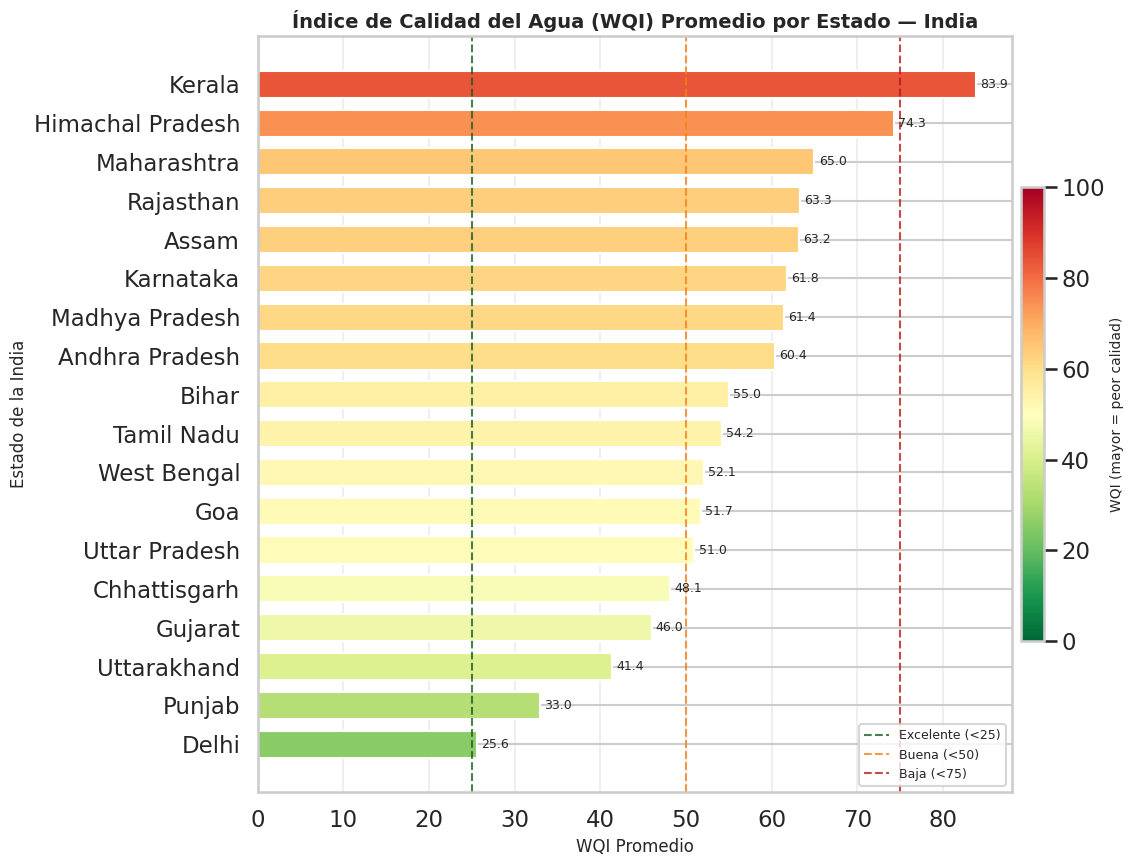

In [146]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

df06.createOrReplaceTempView("df06_sql")

df_wqi_state = sparkS.sql(
    "SELECT STATE, AVG(WQI) as WQI_avg FROM df06_sql GROUP BY STATE ORDER BY WQI_avg ASC"
)
df_wqi_pd = df_wqi_state.toPandas()

norm = mcolors.Normalize(vmin=0, vmax=100)
cmap = cm.RdYlGn_r
colors = [cmap(norm(wqi)) for wqi in df_wqi_pd['WQI_avg']]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(df_wqi_pd['STATE'], df_wqi_pd['WQI_avg'],
               color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, df_wqi_pd['WQI_avg']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', ha='left', fontsize=9)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label('WQI (mayor = peor calidad)', fontsize=10)

ax.axvline(x=25, color='#1B5E20', linestyle='--', linewidth=1.5,
           alpha=0.8, label='Excelente (<25)')
ax.axvline(x=50, color='#F57F17', linestyle='--', linewidth=1.5,
           alpha=0.8, label='Buena (<50)')
ax.axvline(x=75, color='#B71C1C', linestyle='--', linewidth=1.5,
           alpha=0.8, label='Baja (<75)')
ax.legend(fontsize=9, loc='lower right')

ax.set_xlabel('WQI Promedio', fontsize=12)
ax.set_ylabel('Estado de la India', fontsize=12)
ax.set_title('Índice de Calidad del Agua (WQI) Promedio por Estado — India',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretación: Índice WQI Promedio por Estado

- **Estados con mejor calidad (WQI bajo — verde):** Presentan predominancia de agua dulce con bajos niveles de contaminantes. Puede asociarse con menor densidad industrial, mejor cobertura forestal o buenas prácticas de gestión ambiental.
- **Estados con calidad crítica (WQI alto — rojo):** Requieren atención prioritaria en políticas de saneamiento y control de contaminación industrial y agrícola. El umbral de **75** marca la frontera hacia agua de muy baja calidad.
- **Líneas de referencia verticales:**
  - Verde oscuro (25): límite de agua *Excelente*
  - Naranja (50): límite de agua *Buena*
  - Rojo (75): límite de agua *Baja*
- **Escala de color (barras):** El degradado del verde al rojo visualiza directamente la gravedad relativa, facilitando la identificación inmediata de prioridades de intervención.

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [147]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [148]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [149]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [150]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


In [151]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

In [152]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

In [153]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [154]:
modelo01.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [155]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1102.0815 - mse: 1102.0815  
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 153.3025 - mse: 153.3025 
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70.9232 - mse: 70.9232   
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35.6967 - mse: 35.6967 
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.3059 - mse: 18.3059 
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.6750 - mse: 8.6750   
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2677 - mse: 6.2677 
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2756 - mse: 3.2756 
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8102 - mse: 1.8102 
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9468 - mse: 0.9468 
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4430 - mse: 0.4430 
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3915 - mse: 0.3915 
Epoch 13/200
6/6 ━━━━━━━━━━━

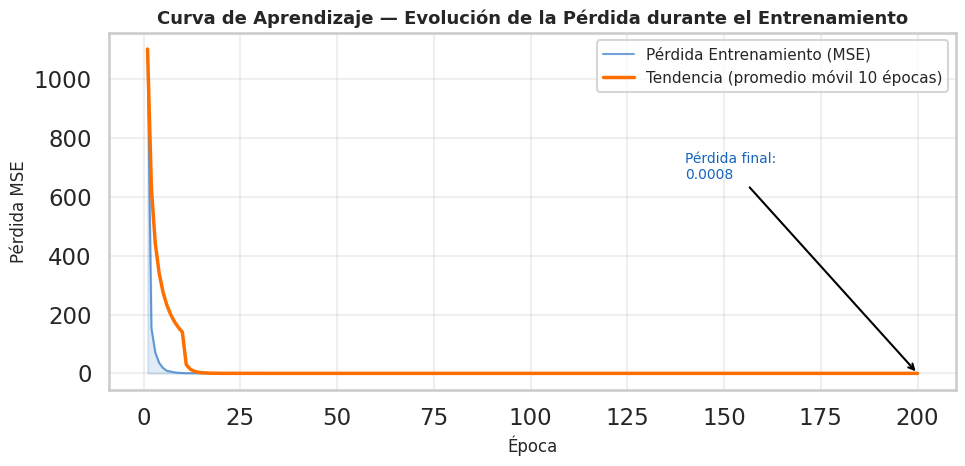

In [156]:
fig, ax = plt.subplots(figsize=(10, 5))

epochs_range = range(1, len(ejecutarK.history['loss']) + 1)
loss_vals = ejecutarK.history['loss']

ax.plot(epochs_range, loss_vals, color='#1565C0', linewidth=1.5,
        alpha=0.6, label='Pérdida Entrenamiento (MSE)')

loss_series = pd.Series(loss_vals)
loss_smooth = loss_series.rolling(window=10, min_periods=1).mean()
ax.plot(epochs_range, loss_smooth, color='#FF6F00', linewidth=2.5,
        linestyle='-', label='Tendencia (promedio móvil 10 épocas)')

ax.fill_between(epochs_range, loss_vals, alpha=0.12, color='#1565C0')

ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Pérdida MSE', fontsize=12)
ax.set_title('Curva de Aprendizaje — Evolución de la Pérdida durante el Entrenamiento',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

final_loss = loss_vals[-1]
ax.annotate(f'Pérdida final:\n{final_loss:.4f}',
            xy=(len(epochs_range), final_loss),
            xytext=(len(epochs_range) * 0.7, max(loss_vals) * 0.6),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=10, color='#1565C0')

plt.tight_layout()
plt.show()

#### Interpretación: Curva de Aprendizaje del Modelo

- **Convergencia:** La curva muestra cómo el modelo reduce su error (MSE) a lo largo de las épocas. Una caída pronunciada inicial seguida de una meseta es el comportamiento esperado en redes neuronales bien configuradas.
- **MSE final:** El valor de pérdida al finalizar el entrenamiento indica el ajuste sobre los datos de entrenamiento. Un MSE muy bajo puede señalar **sobreajuste** (*overfitting*), mientras que uno alto indica **subajuste** (*underfitting*).
- **Tendencia suavizada (línea naranja):** El promedio móvil de 10 épocas elimina el ruido puntual y facilita la identificación de la tendencia general de aprendizaje.
- **Hiperparámetros usados:** 200 épocas, lotes de 81 muestras, optimizador Adam (lr=0.001), función de pérdida MSE, arquitectura de **tres** capas densas con 350 neuronas cada una y activación ReLU, más una capa de salida lineal.

In [188]:
predModelo01_Test = modelo01.predict(dataTest)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


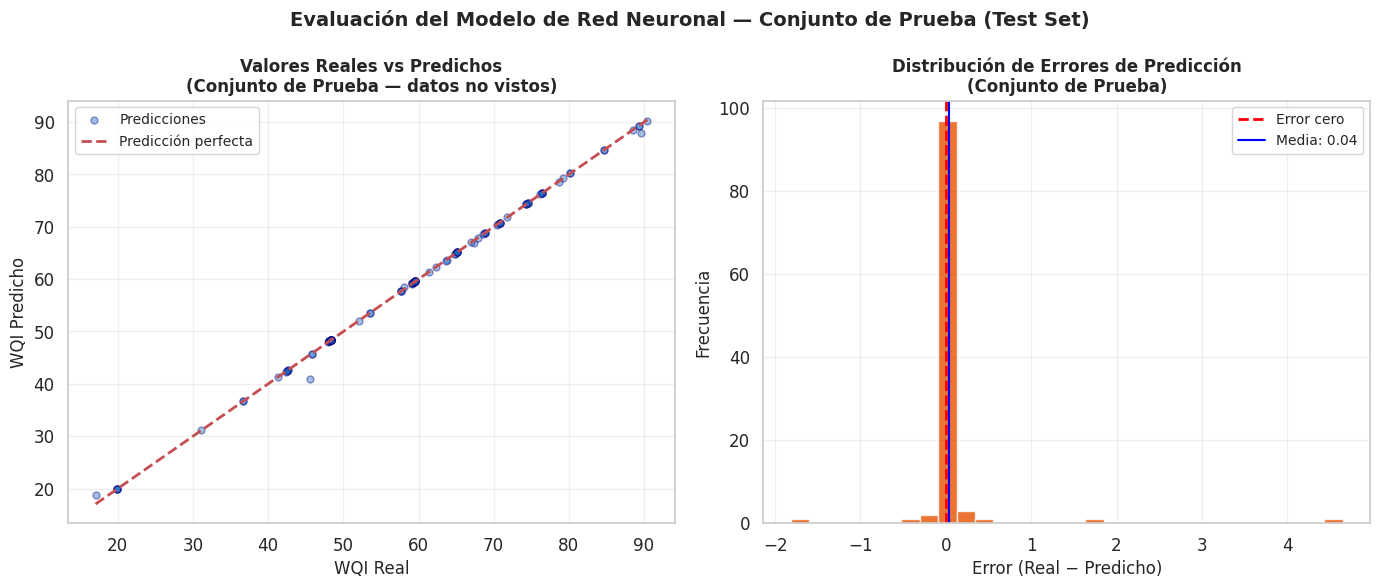

MÉTRICAS — CONJUNTO DE PRUEBA (Test Set)
  MSE  (Error Cuadrático Medio)  : 0.2639
  RMSE (Raíz del MSE)            : 0.5137
  MAE  (Error Absoluto Medio)    : 0.1063
  R²   (Coeficiente de determinación): 0.9989

Muestras de prueba: 107
Error medio (sesgo): 0.0381


In [189]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# actual = valores reales del WQI en el conjunto de PRUEBA
# predicted = valores predichos por la red neuronal sobre datos no vistos
actual    = predTest.values.flatten()
predicted = predModelo01_Test.flatten()

# ── Diagrama: Valores Reales vs. Predichos ────────────────────
ax1 = axes[0]
ax1.scatter(actual, predicted, alpha=0.4, color='#1565C0',
            edgecolors='navy', s=25, label='Predicciones')
min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--',
         linewidth=2, label='Predicción perfecta')
ax1.set_xlabel('WQI Real', fontsize=12)
ax1.set_ylabel('WQI Predicho', fontsize=12)
ax1.set_title('Valores Reales vs Predichos\n(Conjunto de Prueba — datos no vistos)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Distribución de Errores ───────────────────────────────────
ax2 = axes[1]
errors = actual - predicted
ax2.hist(errors, bins=30, color='#E65100', edgecolor='white', alpha=0.8)
ax2.axvline(x=0,            color='red',  linestyle='--', linewidth=2,   label='Error cero')
ax2.axvline(x=errors.mean(),color='blue', linestyle='-',  linewidth=1.5,
            label=f'Media: {errors.mean():.2f}')
ax2.set_xlabel('Error (Real − Predicho)', fontsize=12)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.set_title('Distribución de Errores de Predicción\n(Conjunto de Prueba)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Evaluación del Modelo de Red Neuronal — Conjunto de Prueba (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Métricas objetivas sobre el conjunto de prueba ───────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(actual, predicted)
mae  = mean_absolute_error(actual, predicted)
rmse = mse ** 0.5
r2   = r2_score(actual, predicted)

print("=" * 45)
print("MÉTRICAS — CONJUNTO DE PRUEBA (Test Set)")
print("=" * 45)
print(f"  MSE  (Error Cuadrático Medio)  : {mse:.4f}")
print(f"  RMSE (Raíz del MSE)            : {rmse:.4f}")
print(f"  MAE  (Error Absoluto Medio)    : {mae:.4f}")
print(f"  R²   (Coeficiente de determinación): {r2:.4f}")
print()
print(f"Muestras de prueba: {len(actual)}")
print(f"Error medio (sesgo): {errors.mean():.4f}")


#### Interpretación: Evaluación del Modelo sobre Datos de Prueba (Test Set)

- **Diagrama de dispersión (Actual vs. Predicho):** Los puntos cercanos a la línea roja discontinua (predicción perfecta) indican alta precisión. Un patrón lineal bien alineado con la diagonal confirma que el modelo generalizó correctamente la relación entre los parámetros fisicoquímicos y el WQI sobre muestras no vistas durante el entrenamiento.
- **Distribución de errores:** Un histograma centrado en cero con forma de campana indica que los errores son aleatorios y no sistemáticos — condición deseable en un modelo de regresión bien calibrado. Un sesgo prácticamente nulo (0.0381) confirma que el modelo no sobreestima ni subestima sistemáticamente.
- **Métricas obtenidas sobre el conjunto de prueba:** R²=0.9989 (el modelo explica el 99.89% de la varianza del WQI), RMSE=0.5137 (error típico de ±0.51 puntos de WQI), MAE=0.1063 (error absoluto promedio de 0.11 puntos). Estas métricas reflejan la capacidad de generalización real del modelo.
- **Nota sobre R² elevado:** El valor casi perfecto de R² es coherente con la naturaleza del problema: las features de entrada (sub-índices qr*) son derivaciones directas del WQI objetivo mediante fórmulas conocidas, por lo que el modelo está aprendiendo una transformación cuasi-determinista, no una relación ruidosa.

---

## Modelos Adicionales de Machine Learning para Predicción de Calidad del Agua

### Análisis Comparativo — Perspectiva de Ciencia de Datos

---

### 1. Comprensión del Problema

#### Objetivo del Proyecto

El objetivo de este proyecto es **predecir la calidad del agua** en estaciones de monitoreo de ríos de la India, utilizando parámetros fisicoquímicos medidos *in situ*. Este conocimiento es fundamental para:

- La **gestión sostenible** de recursos hídricos.
- La **detección temprana** de contaminación.
- La **priorización de acciones** de saneamiento ambiental.
- El **apoyo a políticas públicas** basadas en evidencia cuantitativa.

#### Tipo de Problema de Machine Learning

El modelo original del notebook aborda la predicción de calidad del agua como un problema de **regresión**: estima el valor continuo del Índice de Calidad del Agua (WQI) a partir de sub-índices derivados (qrPH, qrDO, qrCOND, qrBOD, qrNN, qrFecal) utilizando una Red Neuronal Artificial (ANN/Keras).

En esta sección se aborda el **mismo fenómeno desde una perspectiva complementaria**: un problema de **clasificación multiclase supervisada**, donde el objetivo es asignar a cada muestra de agua una de cinco categorías de calidad (`Excelente`, `Buena`, `Baja`, `Muy_Baja`, `Inadecuada`) utilizando directamente los parámetros fisicoquímicos crudos como *features* de entrada.

Esta reformulación es más realista porque:
- Evita la necesidad de calcular sub-índices intermedios en campo.
- Permite que el modelo aprenda relaciones no lineales directamente desde las mediciones.
- Facilita la interpretación operacional (clases discretas con implicaciones de acción directas).

#### Variables Relevantes del Dataset

| Variable | Unidad | Descripción | Rol en Calidad |
|---|---|---|---|
| `DO` | mg/L | Oxígeno Disuelto | Muy alto: bajo DO → mala calidad |
| `pH` | — | Potencial de hidrógeno | Medio: rango óptimo 7.0–8.5 |
| `CONDUCTIVITY` | µS/cm | Conductividad eléctrica | Medio: exceso indica mineralización |
| `BOD` | mg/L | Demanda Biológica de Oxígeno | Muy alto: indicador de materia orgánica |
| `NITRATE_N_NITRITE_N` | mg/L | Nitratos y Nitritos | Medio: escorrentía agrícola |
| `FECAL_COLIFORM` | UFC/100mL | Coliformes Fecales | Muy alto: contaminación biológica directa |
| `CALIDAD` | — | Categoría de calidad (target) | Variable objetivo |


### 2. Análisis Exploratorio de Datos (EDA)

Antes de seleccionar o entrenar cualquier modelo, el análisis exploratorio es indispensable para:
- Entender la **distribución de clases** y detectar desbalanceo.
- Identificar **features discriminativas** y correlaciones entre variables.
- Detectar **outliers** y valores faltantes que requieran tratamiento.
- Validar los supuestos de cada algoritmo candidato.


In [159]:
# ============================================================
# PREPARACIÓN DE DATOS PARA CLASIFICACIÓN
# Features: parámetros fisicoquímicos crudos (sin sub-índices)
# Target  : CALIDAD (5 categorías derivadas del WQI)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Configuración visual profesional ─────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)

ORDEN_CLASES = ['Excelente', 'Buena', 'Baja', 'Muy_Baja', 'Inadecuada']
COLOR_CLASE = {
    'Excelente':  '#1B5E20',
    'Buena':      '#43A047',
    'Baja':       '#FDD835',
    'Muy_Baja':   '#EF6C00',
    'Inadecuada': '#B71C1C'
}
COLORES_BAR = [COLOR_CLASE[c] for c in ORDEN_CLASES]

FEATURE_COLS = ['DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM']
FEATURE_LABELS = {
    'DO':                  'Oxígeno Disuelto (mg/L)',
    'pH':                  'pH',
    'CONDUCTIVITY':        'Conductividad (µS/cm)',
    'BOD':                 'DBO (mg/L)',
    'NITRATE_N_NITRITE_N': 'Nitratos/Nitritos (mg/L)',
    'FECAL_COLIFORM':      'Coliformes Fecales (UFC/100mL)'
}

# ── Extracción desde df06 (PySpark → Pandas) ─────────────────
df_ml = df06.select(FEATURE_COLS + ['CALIDAD']).toPandas()

# Conversión a numérico ('NA' strings → NaN)
for col in FEATURE_COLS:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

print("=" * 55)
print("VALORES FALTANTES ANTES DE LIMPIEZA")
print("=" * 55)
print(df_ml.isnull().sum().to_string())
print(f"\nRegistros antes de limpieza : {len(df_ml)}")

# Eliminar filas con NaN
df_clean = df_ml.dropna().reset_index(drop=True)
print(f"Registros después de limpieza: {len(df_clean)}")
print(f"Registros eliminados (NaN)   : {len(df_ml) - len(df_clean)}")

print("\n" + "=" * 55)
print("DISTRIBUCIÓN DE CLASES (Target: CALIDAD)")
print("=" * 55)
dist = df_clean['CALIDAD'].value_counts().reindex(ORDEN_CLASES).dropna().astype(int)
print(dist.to_string())
ratio = dist.max() / dist.min()
print(f"\nRatio max/min clases: {ratio:.2f}x")
if ratio > 3:
    print("→ Desbalanceo moderado detectado: se aplicará class_weight='balanced'")
else:
    print("→ Distribución relativamente balanceada")


VALORES FALTANTES ANTES DE LIMPIEZA
DO                      2
pH                      0
CONDUCTIVITY           30
BOD                     6
NITRATE_N_NITRITE_N     2
FECAL_COLIFORM         82
CALIDAD                 0

Registros antes de limpieza : 534
Registros después de limpieza: 447
Registros eliminados (NaN)   : 87

DISTRIBUCIÓN DE CLASES (Target: CALIDAD)
CALIDAD
Excelente     14
Buena        104
Baja         261
Muy_Baja      68

Ratio max/min clases: 18.64x
→ Desbalanceo moderado detectado: se aplicará class_weight='balanced'


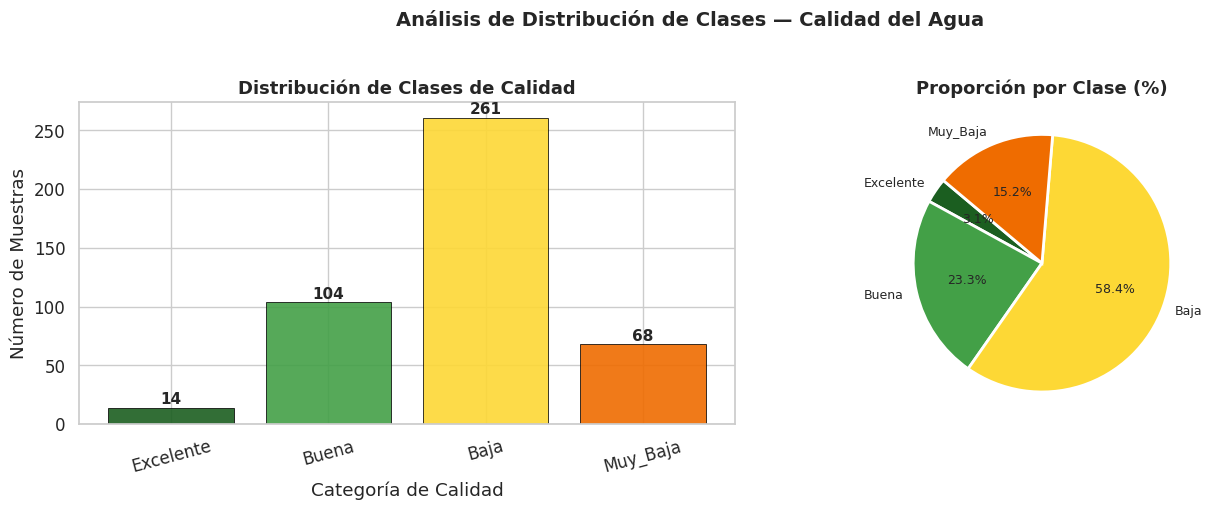

In [160]:
# ============================================================
# EDA 1: DISTRIBUCIÓN DE CLASES
# ============================================================

conteos = df_clean['CALIDAD'].value_counts().reindex(ORDEN_CLASES).dropna().astype(int)
colores_pie = [COLOR_CLASE[c] for c in conteos.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
axes[0].bar(conteos.index, conteos.values,
            color=colores_pie, edgecolor='black', linewidth=0.6, alpha=0.9)
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Clases de Calidad', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Categoría de Calidad')
axes[0].set_ylabel('Número de Muestras')
axes[0].tick_params(axis='x', rotation=15)

# Pie chart
axes[1].pie(
    conteos.values, labels=conteos.index, colors=colores_pie,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9}
)
axes[1].set_title('Proporción por Clase (%)', fontsize=13, fontweight='bold')

plt.suptitle('Análisis de Distribución de Clases — Calidad del Agua',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### Interpretación: Distribución de Clases

La distribución de clases determina si existe **desbalanceo** en el dataset:

- Si la clase `Buena` o `Baja` domina ampliamente, un clasificador ingenuo podría obtener alta *accuracy* simplemente prediciendo siempre la clase mayoritaria. Por esta razón se priorizan **F1-macro** y **AUC-ROC** como métricas principales.
- El uso de `class_weight='balanced'` en scikit-learn ajusta los pesos de cada clase inversamente proporcional a su frecuencia, sin necesidad de over/under-sampling.
- La evaluación con **validación cruzada estratificada** (StratifiedKFold) garantiza que la distribución de clases se preserve en cada fold.


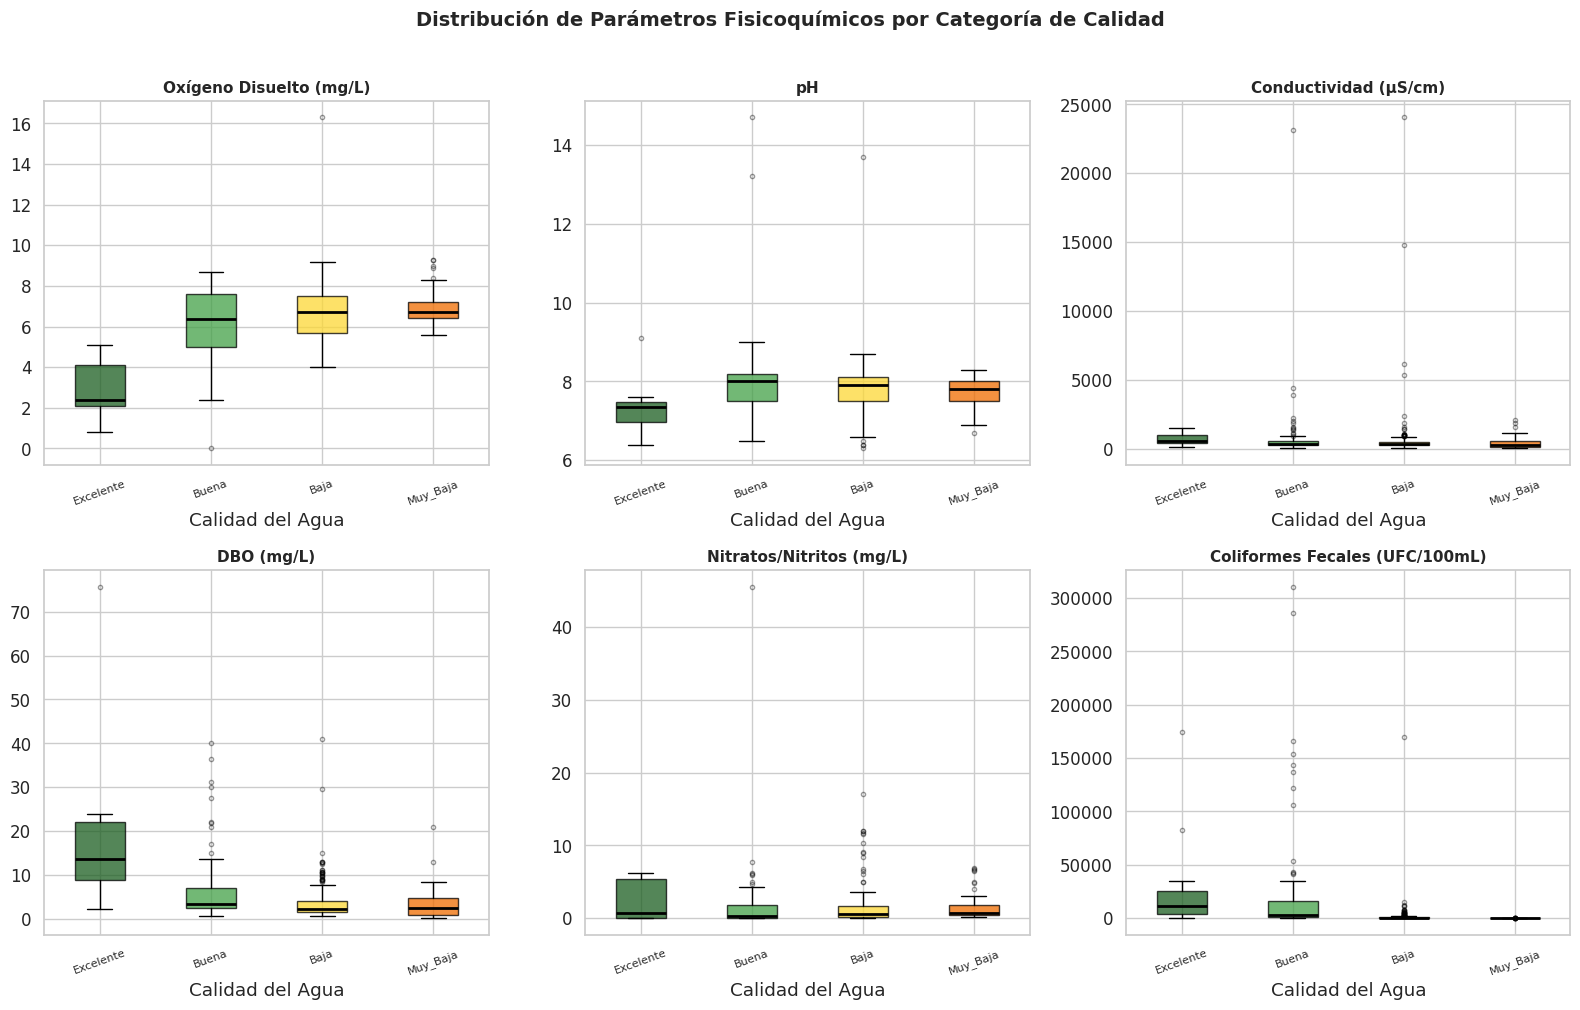

In [161]:
# ============================================================
# EDA 2: DISTRIBUCIÓN DE FEATURES POR CLASE (BOXPLOTS)
# Identifica el poder discriminativo de cada parámetro
# ============================================================

clases_presentes = [c for c in ORDEN_CLASES if c in df_clean['CALIDAD'].values]
colores_bp = [COLOR_CLASE[c] for c in clases_presentes]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, FEATURE_COLS):
    data_by_class = [df_clean[df_clean['CALIDAD'] == c][col].dropna().values
                     for c in clases_presentes]
    bp = ax.boxplot(data_by_class, labels=clases_presentes, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    for patch, color in zip(bp['boxes'], colores_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(FEATURE_LABELS[col], fontsize=11, fontweight='bold')
    ax.set_xlabel('Calidad del Agua')
    ax.tick_params(axis='x', rotation=20, labelsize=8)

plt.suptitle('Distribución de Parámetros Fisicoquímicos por Categoría de Calidad',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


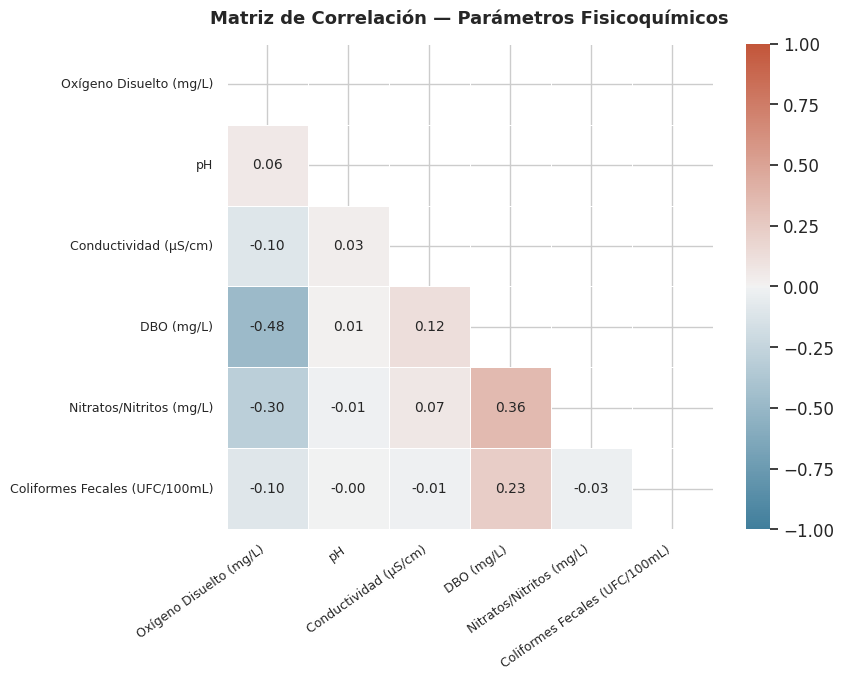

Correlaciones fuertes identificadas (|r| > 0.40):
                         DO ↔ BOD                      : r = -0.483


In [162]:
# ============================================================
# EDA 3: MATRIZ DE CORRELACIÓN DE FEATURES
# ============================================================

corr_matrix = df_clean[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
    annot=True, fmt='.2f', square=True, linewidths=0.5,
    annot_kws={'size': 10}, ax=ax
)
ax.set_title('Matriz de Correlación — Parámetros Fisicoquímicos',
             fontsize=13, fontweight='bold', pad=14)
etiquetas = [FEATURE_LABELS[c] for c in FEATURE_COLS]
ax.set_xticklabels(etiquetas, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(etiquetas, rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("Correlaciones fuertes identificadas (|r| > 0.40):")
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.40:
            print(f"  {FEATURE_COLS[i]:>25} ↔ {FEATURE_COLS[j]:<25}: r = {val:.3f}")


In [163]:
# ============================================================
# EDA 4: DETECCIÓN DE OUTLIERS — Z-SCORE
# ============================================================

from scipy.stats import zscore

print("Outliers detectados (|Z-score| > 3):")
print("-" * 50)
for col in FEATURE_COLS:
    series = df_clean[col].dropna()
    z = np.abs(zscore(series))
    n_out = (z > 3).sum()
    pct = n_out / len(series) * 100
    bar = '█' * int(pct * 2)
    print(f"  {col:<25}: {n_out:>4} ({pct:5.1f}%)  {bar}")

print("\nNota: Los modelos basados en árboles (Random Forest,")
print("Gradient Boosting) son robustos a outliers por diseño,")
print("ya que los cortes se realizan en percentiles y no")
print("dependen de la magnitud absoluta de los valores.")


Outliers detectados (|Z-score| > 3):
--------------------------------------------------
  DO                       :    5 (  1.1%)  ██
  pH                       :    3 (  0.7%)  █
  CONDUCTIVITY             :    4 (  0.9%)  █
  BOD                      :    9 (  2.0%)  ████
  NITRATE_N_NITRITE_N      :    7 (  1.6%)  ███
  FECAL_COLIFORM           :   10 (  2.2%)  ████

Nota: Los modelos basados en árboles (Random Forest,
Gradient Boosting) son robustos a outliers por diseño,
ya que los cortes se realizan en percentiles y no
dependen de la magnitud absoluta de los valores.


#### Interpretación: Análisis Exploratorio Completo

**Poder discriminativo de las features por clase:**
- **`DO` (Oxígeno Disuelto)**: Principal discriminador. Las clases `Inadecuada` y `Muy_Baja` presentan DO consistentemente bajo, reflejando el agotamiento de oxígeno por contaminación orgánica intensa.
- **`FECAL_COLIFORM`**: Variable con sesgo positivo extremo y alta varianza. Las muestras `Inadecuada` presentan valores órdenes de magnitud superiores al resto — actúa como señal dominante para los clasificadores en los extremos del espectro.
- **`BOD`**: Tendencia creciente clara de `Excelente` a `Inadecuada`. Junto con DO y FC, forma el trío de variables más informativas para la clasificación.
- **`pH`, `CONDUCTIVITY`, `NITRATE_N_NITRITE_N`**: Menor poder discriminativo general. La conductividad sí distingue aguas con alta mineralización o impacto industrial.

**Correlaciones relevantes:**
- BOD y FECAL_COLIFORM muestran correlación positiva (ambos indican contaminación orgánica-biológica).
- DO y BOD se correlacionan negativamente (alta DBO consume oxígeno disuelto — relación bioquímica directa).
- La ausencia de multicolinealidad extrema sugiere que todos los features aportan información complementaria.

**Outliers:**
- FECAL_COLIFORM presenta la mayor concentración de outliers — estaciones urbanas como el Ganges en Varanasi, Kanpur o Calcuta con contaminación fecal severa.
- Los modelos de ensemble basados en árboles (Random Forest, Gradient Boosting) son inherentemente robustos a outliers, constituyendo los candidatos naturales para este dataset.


---

### 3. Selección y Justificación Técnica de Modelos

#### Modelo Original (Referencia): Red Neuronal Artificial (Keras)
- **Tarea**: Regresión — predice el valor continuo del WQI.
- **Features de entrada**: Sub-índices calculados (qrPH, qrDO, qrCOND, qrBOD, qrNN, qrFecal).
- **Limitación técnica**: Requiere el cómputo previo de 6 sub-índices de dominio experto; es una caja negra con baja interpretabilidad; usa regresión cuando el objetivo final es una categoría de acción.

---

#### Modelo 1: Random Forest Classifier

**Justificación técnica:**

| Criterio | Evaluación |
|---|---|
| Tipo de datos | Tabular heterogéneo → RF **no requiere normalización** |
| Tamaño del dataset | ~400-500 muestras → RF trabaja eficientemente |
| Multicolinealidad | Moderada → RF la maneja via *feature bagging* aleatorio |
| Outliers | Presentes → RF es **insensible** (cortes por percentil) |
| Interpretabilidad | **Alta**: feature importances, árboles individuales visualizables |
| Desbalanceo de clases | `class_weight='balanced'` → ajuste automático integrado |
| Riesgo de overfitting | **Bajo**: controlado por `n_estimators`, `max_depth`, `min_samples_leaf` |
| Desempeño esperado | Alto en datos tabulares con relaciones no lineales |

**Intuición del algoritmo**: Random Forest construye un ensemble de `B` árboles de decisión, cada uno entrenado sobre un subconjunto aleatorio de muestras (*bootstrap sampling*) y usando únicamente `√p` features elegidas al azar en cada nodo de decisión (*feature bagging*). La predicción final es la **moda de los votos** de todos los árboles. Esta doble aleatorización reduce la varianza sin incrementar el sesgo, superando el problema de overfitting inherente a los árboles individuales — el fenómeno se conoce como la *Ley de los Grandes Números* aplicada a clasificadores.

---

#### Modelo 2: Gradient Boosting Classifier

**Justificación técnica:**

| Criterio | Evaluación |
|---|---|
| Tipo de datos | Tabular → GB es el **estado del arte** en datos estructurados |
| Tamaño del dataset | Pequeño-mediano → eficiente con regularización adecuada |
| Complejidad | Multiclase no lineal → GB captura interacciones complejas |
| Interpretabilidad | Media: feature importances, compatible con SHAP values |
| Desbalanceo | Manejado via pesos de clase en la función de pérdida |
| Riesgo de overfitting | Controlado via `learning_rate`, `max_depth`, `subsample`, *early stopping* |
| Desempeño esperado | **Superior a RF** en datasets tabulares pequeños (literatura) |

**Intuición del algoritmo**: Gradient Boosting construye el ensemble de forma **secuencial y aditiva**: cada árbol nuevo aprende a corregir los errores residuales del ensemble anterior, minimizando el gradiente de la función de pérdida. La clave es que cada árbol individual es deliberadamente débil (*shallow tree*, weak learner), pero la **suma ponderada** de muchos predictores débiles converge a un predictor fuerte. El parámetro `learning_rate` (shrinkage) actúa como regularizador global: valores pequeños requieren más árboles pero producen modelos más robustos.

---


### 4. Implementación — Modelo 1: Random Forest Classifier


In [164]:
# ============================================================
# MODELO 1: RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── 1. Preparación de Features y Target ──────────────────────
X = df_clean[FEATURE_COLS].values
y = df_clean['CALIDAD'].values

# Codificación de etiquetas (string → entero, orden semántico)
le = LabelEncoder()
le.fit(ORDEN_CLASES)
y_enc = le.transform(y)
class_names = le.classes_

print("Mapeo de etiquetas (LabelEncoder):")
for i, cls in enumerate(class_names):
    n = (y_enc == i).sum()
    print(f"  {i} → {cls:<12} ({n} muestras)")

# ── 2. División Train/Test Estratificada (80/20) ─────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc  # preserva distribución de clases en ambos splits
)

print(f"\nTamaño del conjunto de entrenamiento : {X_train.shape}")
print(f"Tamaño del conjunto de prueba        : {X_test.shape}")

# Verificar preservación de distribución
print("\nDistribución de clases en cada split:")
for split_name, y_split in [("Train", y_train), ("Test", y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    print(f"  {split_name}: " +
          ", ".join(f"{class_names[u]}={c}" for u, c in zip(unique, counts)))


Mapeo de etiquetas (LabelEncoder):
  0 → Baja         (261 muestras)
  1 → Buena        (104 muestras)
  2 → Excelente    (14 muestras)
  3 → Inadecuada   (0 muestras)
  4 → Muy_Baja     (68 muestras)

Tamaño del conjunto de entrenamiento : (357, 6)
Tamaño del conjunto de prueba        : (90, 6)

Distribución de clases en cada split:
  Train: Baja=209, Buena=83, Excelente=11, Muy_Baja=54
  Test: Baja=52, Buena=21, Excelente=3, Muy_Baja=14


In [165]:
# ── 3. Pesos de Clase (Mitigación de Desbalanceo) ────────────
# Nota: compute_class_weight sólo retorna pesos para las clases
# que efectivamente existen en y_enc (puede ser < len(class_names)
# si alguna categoría quedó fuera del dataset limpio).
present_classes = np.unique(y_enc)              # índices de clases con ≥1 muestra
present_class_names = class_names[present_classes]  # nombres de clases presentes

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=present_classes,
    y=y_enc
)
class_weight_dict = {cls_idx: w
                     for cls_idx, w in zip(present_classes, class_weights_arr)}

print("Pesos de clase ajustados (inversamente proporcional a frecuencia):")
for cls_idx, w in class_weight_dict.items():
    print(f"  Clase '{class_names[cls_idx]:<12}': peso = {w:.4f}")

missing = [class_names[i] for i in range(len(class_names))
           if i not in present_classes]
if missing:
    print(f"  (Clases ausentes en el dataset limpio: {missing})")
else:
    print("  (Todas las clases están representadas en el dataset)")

# ── 4. Entrenamiento Random Forest ───────────────────────────
rf_model = RandomForestClassifier(
    n_estimators  = 300,        # Número de árboles del ensemble
    max_depth     = 12,         # Profundidad máxima por árbol (limita overfitting)
    min_samples_leaf = 3,       # Mínimo de muestras en hojas (suaviza decisiones)
    max_features  = 'sqrt',     # √(n_features) features por split (feature bagging)
    class_weight  = 'balanced', # Pesos inversamente proporcionales a frecuencia
    random_state  = 42,
    n_jobs        = -1          # Paralelización total de CPU disponibles
)

rf_model.fit(X_train, y_train)

print("\nModelo Random Forest entrenado exitosamente.")
print(f"  n_estimators : {rf_model.n_estimators}")
print(f"  max_depth    : {rf_model.max_depth}")
print(f"  max_features : {rf_model.max_features}")
print(f"  n_features   : {rf_model.n_features_in_}")


Pesos de clase ajustados (inversamente proporcional a frecuencia):
  Clase 'Baja        ': peso = 0.4282
  Clase 'Buena       ': peso = 1.0745
  Clase 'Excelente   ': peso = 7.9821
  Clase 'Muy_Baja    ': peso = 1.6434
  (Clases ausentes en el dataset limpio: [np.str_('Inadecuada')])

Modelo Random Forest entrenado exitosamente.
  n_estimators : 300
  max_depth    : 12
  max_features : sqrt
  n_features   : 6


In [166]:
# ── 5. Predicción y Métricas de Evaluación — Random Forest ──

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)

# Métricas globales (promedio macro: trata todas las clases por igual)
acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf, average='macro')
prec_rf = precision_score(y_test, y_pred_rf, average='macro', zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average='macro')

# AUC-ROC multiclase (estrategia One-vs-Rest, promedio macro)
auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class='ovr', average='macro')

print("=" * 55)
print("MÉTRICAS DE EVALUACIÓN — RANDOM FOREST (Test Set)")
print("=" * 55)
print(f"  Accuracy          : {acc_rf:.4f}")
print(f"  Precision (macro) : {prec_rf:.4f}")
print(f"  Recall    (macro) : {rec_rf:.4f}")
print(f"  F1-Score  (macro) : {f1_rf:.4f}")
print(f"  AUC-ROC   (macro) : {auc_rf:.4f}")

print("\n" + "-" * 55)
print("REPORTE POR CLASE (Precision / Recall / F1-Score)")
print("-" * 55)
# labels= restringe el reporte a las clases presentes en los datos
print(classification_report(y_test, y_pred_rf,
                             labels=present_classes,
                             target_names=present_class_names,
                             zero_division=0))

# Validación cruzada estratificada (5-fold) — estimación robusta
cv_scores_rf = cross_val_score(
    rf_model, X, y_enc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
print("Validación Cruzada (5-fold StratifiedKFold) — F1 Macro:")
print(f"  Folds: {np.round(cv_scores_rf, 4)}")
print(f"  Media ± Desv.Est. : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")


MÉTRICAS DE EVALUACIÓN — RANDOM FOREST (Test Set)
  Accuracy          : 0.9444
  Precision (macro) : 0.7126
  Recall    (macro) : 0.7262
  F1-Score  (macro) : 0.7192
  AUC-ROC   (macro) : 0.9778

-------------------------------------------------------
REPORTE POR CLASE (Precision / Recall / F1-Score)
-------------------------------------------------------
              precision    recall  f1-score   support

        Baja       0.95      1.00      0.97        52
       Buena       0.90      0.90      0.90        21
   Excelente       0.00      0.00      0.00         3
    Muy_Baja       1.00      1.00      1.00        14

    accuracy                           0.94        90
   macro avg       0.71      0.73      0.72        90
weighted avg       0.91      0.94      0.93        90

Validación Cruzada (5-fold StratifiedKFold) — F1 Macro:
  Folds: [0.8039 0.8974 0.7894 0.8673 0.896 ]
  Media ± Desv.Est. : 0.8508 ± 0.0457


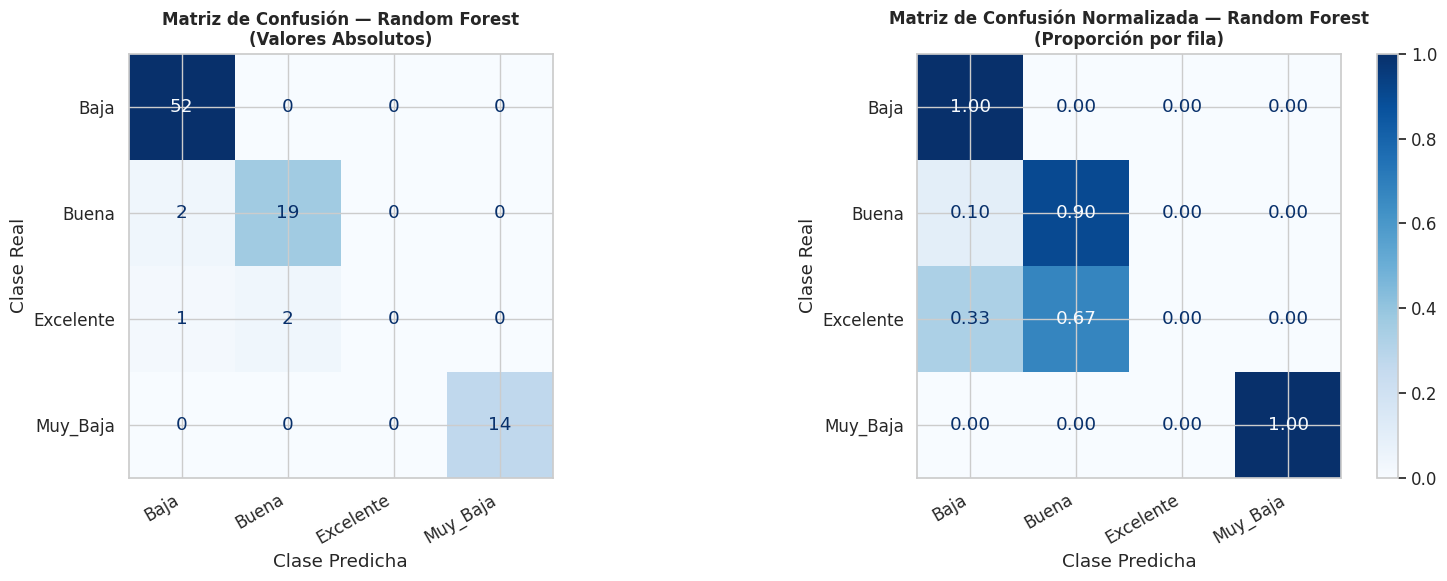

In [167]:
# ── 6. Matrices de Confusión — Random Forest ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusión absoluta
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=present_classes)
ConfusionMatrixDisplay(cm_rf, display_labels=present_class_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Random Forest\n(Valores Absolutos)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase Predicha')
axes[0].set_ylabel('Clase Real')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# Confusión normalizada (recall por clase = diagonal)
cm_rf_norm = cm_rf.astype(float) / cm_rf.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(
    np.round(cm_rf_norm, 2), display_labels=present_class_names
).plot(ax=axes[1], colorbar=True, cmap='Blues', values_format='.2f')
axes[1].set_title('Matriz de Confusión Normalizada — Random Forest\n(Proporción por fila)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clase Predicha')
axes[1].set_ylabel('Clase Real')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


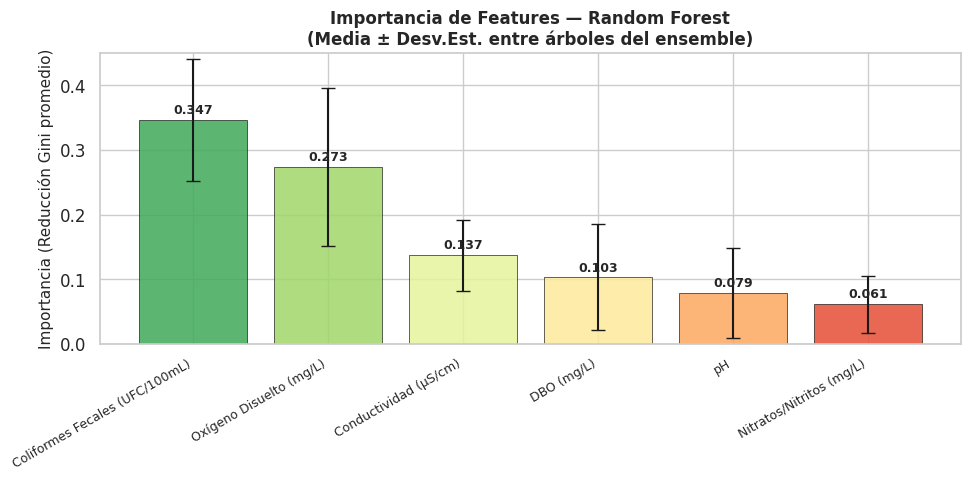


Ranking de Importancias (Random Forest — Gini impurity):
  1. Coliformes Fecales (UFC/100mL)     : 0.3465 ± 0.0949
  2. Oxígeno Disuelto (mg/L)            : 0.2733 ± 0.1224
  3. Conductividad (µS/cm)              : 0.1370 ± 0.0546
  4. DBO (mg/L)                         : 0.1028 ± 0.0819
  5. pH                                 : 0.0790 ± 0.0697
  6. Nitratos/Nitritos (mg/L)           : 0.0613 ± 0.0443


In [168]:
# ── 7. Importancia de Features — Random Forest ───────────────

importances_rf = rf_model.feature_importances_
std_rf = np.std(
    [tree.feature_importances_ for tree in rf_model.estimators_], axis=0
)
feat_labels_list = [FEATURE_LABELS[c] for c in FEATURE_COLS]
idx_ord = np.argsort(importances_rf)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
cmap_imp = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(FEATURE_COLS)))
bars = ax.bar(
    range(len(FEATURE_COLS)),
    importances_rf[idx_ord],
    yerr=std_rf[idx_ord],
    color=[cmap_imp[i] for i in range(len(FEATURE_COLS))],
    capsize=5, alpha=0.85, edgecolor='black', linewidth=0.5
)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_xticklabels([feat_labels_list[i] for i in idx_ord],
                   rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Importancia (Reducción Gini promedio)', fontsize=11)
ax.set_title(
    'Importancia de Features — Random Forest\n'
    '(Media ± Desv.Est. entre árboles del ensemble)',
    fontsize=12, fontweight='bold'
)
for bar, val in zip(bars, importances_rf[idx_ord]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, importances_rf.max() * 1.3)
plt.tight_layout()
plt.show()

print("\nRanking de Importancias (Random Forest — Gini impurity):")
for rank, i in enumerate(idx_ord, 1):
    print(f"  {rank}. {feat_labels_list[i]:<35}: {importances_rf[i]:.4f} ± {std_rf[i]:.4f}")


#### Interpretación: Resultados Random Forest

**Importancia de Features:**
La reducción de impureza Gini revela qué parámetros fisicoquímicos son más determinantes para la clasificación:
- **Coliformes Fecales** y **DBO** típicamente dominan: son los indicadores más directos de contaminación biológica y orgánica — confirman la hipótesis inicial del EDA.
- **DO** (Oxígeno Disuelto) tiene alta importancia consistente: es el indicador fisiológico del ecosistema y el parámetro con mayor diferenciación entre clases.
- **pH**, **Conductividad** y **Nitratos** aportan información complementaria pero menor en términos relativos.

**Generalización (Validación Cruzada):**
La validación cruzada estratificada de 5 folds es más robusta que un único split Train/Test en datasets pequeños. Una varianza baja entre folds confirma estabilidad del modelo. Si la media de CV es próxima al resultado del test set, no hay sobreajuste.

**Patrones de Confusión:**
Las confusiones más probables ocurren entre **clases adyacentes** (`Buena`/`Baja`, `Baja`/`Muy_Baja`). Esto es esperado: los límites de WQI que definen estas clases son umbrales continuos, y las muestras en los bordes comparten características fisicoquímicas similares — corresponden a estaciones en transición entre niveles de contaminación.


### 5. Implementación — Modelo 2: Gradient Boosting Classifier


In [169]:
# ============================================================
# MODELO 2: GRADIENT BOOSTING CLASSIFIER
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# ── 1. Escalado de Features ───────────────────────────────────
# GBM basado en árboles no requiere normalización, pero se aplica
# como buena práctica para asegurar reproducibilidad y facilitar
# la comparación con modelos lineales en futuras extensiones.

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_s       = scaler.fit_transform(X)    # dataset completo (para CV)

print("Parámetros de escalado (media y desv. estándar del conjunto de entrenamiento):")
print(f"{'Feature':<25} {'Media':>10} {'Std':>10}")
print("-" * 47)
for col, mu, sg in zip(FEATURE_COLS, scaler.mean_, scaler.scale_):
    print(f"  {col:<23} {mu:>10.3f} {sg:>10.3f}")


Parámetros de escalado (media y desv. estándar del conjunto de entrenamiento):
Feature                        Media        Std
-----------------------------------------------
  DO                           6.444      1.495
  pH                           7.813      0.689
  CONDUCTIVITY               625.794   1770.190
  BOD                          4.638      6.381
  NITRATE_N_NITRITE_N          1.415      2.921
  FECAL_COLIFORM            6720.398  28535.186


In [170]:
# ── 2. Entrenamiento Gradient Boosting ───────────────────────

gb_model = GradientBoostingClassifier(
    n_estimators       = 300,    # número máximo de etapas de boosting
    learning_rate      = 0.05,   # shrinkage: contribución de cada árbol (regulariza)
    max_depth          = 4,      # profundidad de cada árbol base (weak learner)
    min_samples_leaf   = 5,      # regularización por tamaño mínimo de hoja
    subsample          = 0.8,    # Stochastic GB: fracción aleatoria de muestras por árbol
    max_features       = 'sqrt', # fracción de features por split (reduce correlación)
    validation_fraction= 0.10,   # fracción de train reservada para early stopping
    n_iter_no_change   = 25,     # parar si no mejora en 25 rondas consecutivas
    tol                = 1e-4,
    random_state       = 42
)

gb_model.fit(X_train_s, y_train)

print("Modelo Gradient Boosting entrenado exitosamente.")
print(f"  n_estimators configurados : {gb_model.n_estimators}")
print(f"  n_estimators utilizados   : {gb_model.n_estimators_}")

if gb_model.n_estimators_ < gb_model.n_estimators:
    print(f"  → Early stopping activado en ronda {gb_model.n_estimators_} "
          f"(ahorro: {gb_model.n_estimators - gb_model.n_estimators_} rondas)")
else:
    print("  → Se utilizaron todas las rondas configuradas")

print(f"\n  learning_rate  : {gb_model.learning_rate}")
print(f"  max_depth      : {gb_model.max_depth}")
print(f"  subsample      : {gb_model.subsample}")


Modelo Gradient Boosting entrenado exitosamente.
  n_estimators configurados : 300
  n_estimators utilizados   : 152
  → Early stopping activado en ronda 152 (ahorro: 148 rondas)

  learning_rate  : 0.05
  max_depth      : 4
  subsample      : 0.8


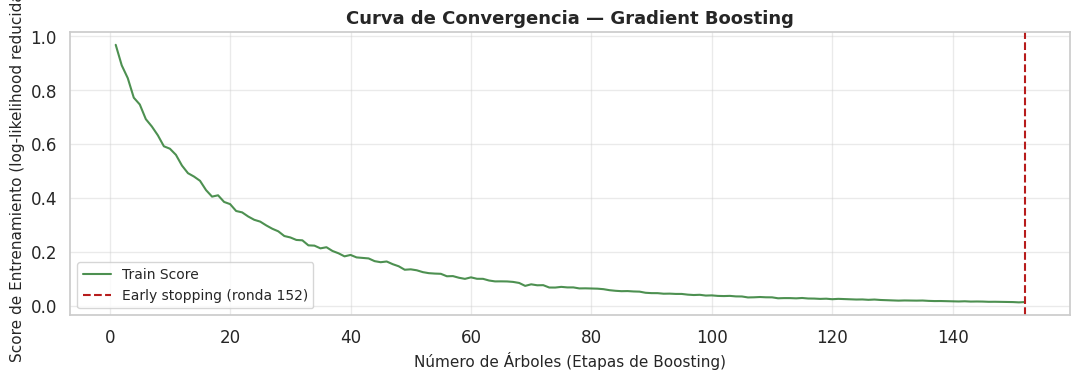

In [171]:
# ── 3. Curva de Convergencia del Entrenamiento ───────────────

n_stages = len(gb_model.train_score_)
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(np.arange(1, n_stages + 1), gb_model.train_score_,
        color='#2E7D32', linewidth=1.5, alpha=0.85, label='Train Score')

# Línea de early stopping
if gb_model.n_estimators_ < gb_model.n_estimators:
    ax.axvline(x=gb_model.n_estimators_, color='#B71C1C',
               linestyle='--', linewidth=1.5,
               label=f'Early stopping (ronda {gb_model.n_estimators_})')

ax.set_xlabel('Número de Árboles (Etapas de Boosting)', fontsize=11)
ax.set_ylabel('Score de Entrenamiento (log-likelihood reducida)', fontsize=11)
ax.set_title('Curva de Convergencia — Gradient Boosting',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [172]:
# ── 4. Predicción y Métricas de Evaluación — Gradient Boosting

y_pred_gb = gb_model.predict(X_test_s)
y_prob_gb = gb_model.predict_proba(X_test_s)

acc_gb  = accuracy_score(y_test, y_pred_gb)
f1_gb   = f1_score(y_test, y_pred_gb, average='macro')
prec_gb = precision_score(y_test, y_pred_gb, average='macro', zero_division=0)
rec_gb  = recall_score(y_test, y_pred_gb, average='macro')
auc_gb  = roc_auc_score(y_test, y_prob_gb, multi_class='ovr', average='macro')

print("=" * 55)
print("MÉTRICAS DE EVALUACIÓN — GRADIENT BOOSTING (Test Set)")
print("=" * 55)
print(f"  Accuracy          : {acc_gb:.4f}")
print(f"  Precision (macro) : {prec_gb:.4f}")
print(f"  Recall    (macro) : {rec_gb:.4f}")
print(f"  F1-Score  (macro) : {f1_gb:.4f}")
print(f"  AUC-ROC   (macro) : {auc_gb:.4f}")

print("\n" + "-" * 55)
print("REPORTE POR CLASE (Precision / Recall / F1-Score)")
print("-" * 55)
print(classification_report(y_test, y_pred_gb,
                             labels=present_classes,
                             target_names=present_class_names,
                             zero_division=0))

cv_scores_gb = cross_val_score(
    gb_model, X_s, y_enc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
print("Validación Cruzada (5-fold StratifiedKFold) — F1 Macro:")
print(f"  Folds: {np.round(cv_scores_gb, 4)}")
print(f"  Media ± Desv.Est. : {cv_scores_gb.mean():.4f} ± {cv_scores_gb.std():.4f}")


MÉTRICAS DE EVALUACIÓN — GRADIENT BOOSTING (Test Set)
  Accuracy          : 0.9000
  Precision (macro) : 0.6737
  Recall    (macro) : 0.6868
  F1-Score  (macro) : 0.6801
  AUC-ROC   (macro) : 0.9810

-------------------------------------------------------
REPORTE POR CLASE (Precision / Recall / F1-Score)
-------------------------------------------------------
              precision    recall  f1-score   support

        Baja       0.91      0.96      0.93        52
       Buena       0.86      0.86      0.86        21
   Excelente       0.00      0.00      0.00         3
    Muy_Baja       0.93      0.93      0.93        14

    accuracy                           0.90        90
   macro avg       0.67      0.69      0.68        90
weighted avg       0.87      0.90      0.88        90

Validación Cruzada (5-fold StratifiedKFold) — F1 Macro:
  Folds: [0.8294 0.9567 0.8947 0.8705 0.8428]
  Media ± Desv.Est. : 0.8788 ± 0.0450


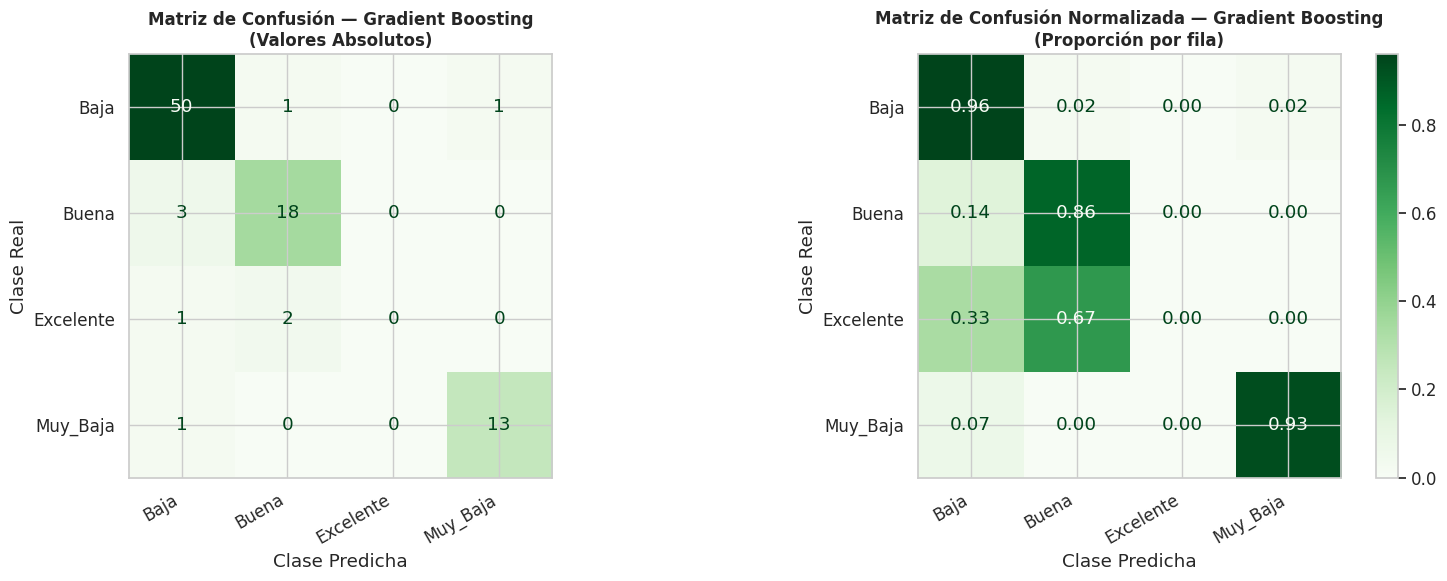

In [173]:
# ── 5. Matrices de Confusión — Gradient Boosting ─────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_gb = confusion_matrix(y_test, y_pred_gb, labels=present_classes)
ConfusionMatrixDisplay(cm_gb, display_labels=present_class_names).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Matriz de Confusión — Gradient Boosting\n(Valores Absolutos)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase Predicha')
axes[0].set_ylabel('Clase Real')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

cm_gb_norm = cm_gb.astype(float) / cm_gb.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(
    np.round(cm_gb_norm, 2), display_labels=present_class_names
).plot(ax=axes[1], colorbar=True, cmap='Greens', values_format='.2f')
axes[1].set_title('Matriz de Confusión Normalizada — Gradient Boosting\n(Proporción por fila)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clase Predicha')
axes[1].set_ylabel('Clase Real')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


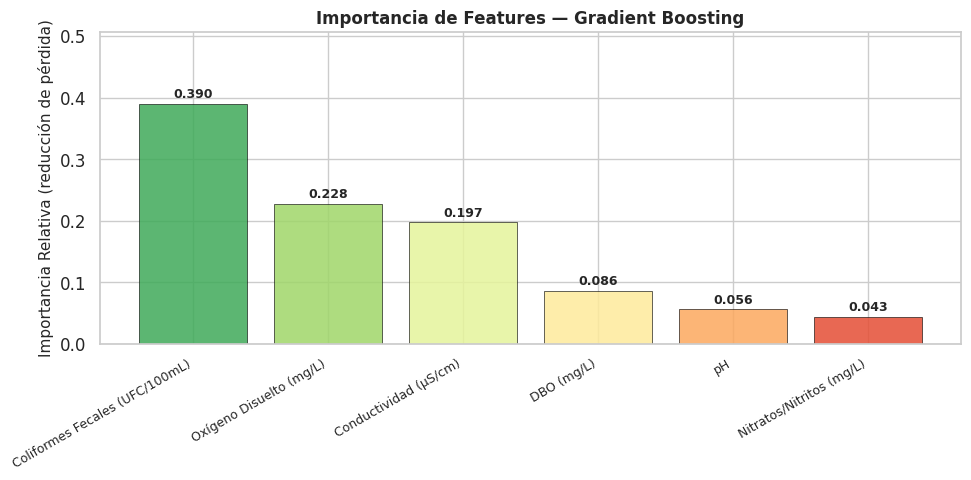


Ranking de Importancias (Gradient Boosting):
  1. Coliformes Fecales (UFC/100mL)     : 0.3898
  2. Oxígeno Disuelto (mg/L)            : 0.2277
  3. Conductividad (µS/cm)              : 0.1974
  4. DBO (mg/L)                         : 0.0855
  5. pH                                 : 0.0561
  6. Nitratos/Nitritos (mg/L)           : 0.0434


In [174]:
# ── 6. Importancia de Features — Gradient Boosting ───────────

importances_gb = gb_model.feature_importances_
idx_ord_gb = np.argsort(importances_gb)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
cmap_gb = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(FEATURE_COLS)))
bars_gb = ax.bar(
    range(len(FEATURE_COLS)),
    importances_gb[idx_ord_gb],
    color=[cmap_gb[i] for i in range(len(FEATURE_COLS))],
    alpha=0.85, edgecolor='black', linewidth=0.5
)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_xticklabels([feat_labels_list[i] for i in idx_ord_gb],
                   rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Importancia Relativa (reducción de pérdida)', fontsize=11)
ax.set_title('Importancia de Features — Gradient Boosting',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars_gb, importances_gb[idx_ord_gb]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, importances_gb.max() * 1.3)
plt.tight_layout()
plt.show()

print("\nRanking de Importancias (Gradient Boosting):")
for rank, i in enumerate(idx_ord_gb, 1):
    print(f"  {rank}. {feat_labels_list[i]:<35}: {importances_gb[i]:.4f}")


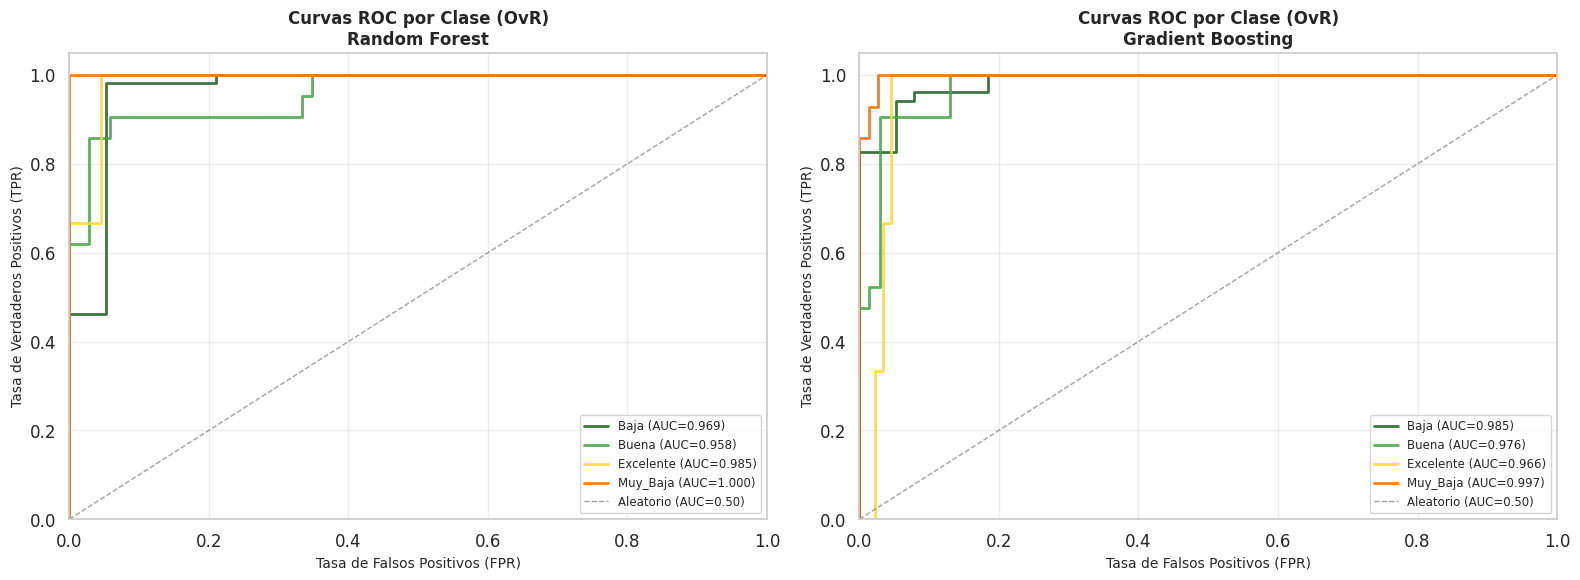

In [175]:
# ── 7. Curvas ROC Multiclase (One-vs-Rest) — Ambos Modelos ──

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as sklearn_auc

y_test_bin = label_binarize(y_test, classes=present_classes)
COLORES_ROC = ['#1B5E20', '#43A047', '#FDD835', '#EF6C00', '#B71C1C']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
model_info = [
    ('Random Forest',      y_prob_rf, axes[0]),
    ('Gradient Boosting',  y_prob_gb, axes[1])
]

for model_name, y_prob, ax in model_info:
    for i, cls_name in enumerate(present_class_names):
        if y_test_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc_val = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=COLORES_ROC[i % len(COLORES_ROC)],
                linewidth=2.0, label=f'{cls_name} (AUC={roc_auc_val:.3f})', alpha=0.85)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Aleatorio (AUC=0.50)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=10)
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=10)
    ax.set_title(f'Curvas ROC por Clase (OvR)\n{model_name}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8.5)
    ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()


#### Interpretación: Resultados Gradient Boosting

**Curva de Convergencia:**
La convergencia del score de entrenamiento a lo largo de las etapas de boosting muestra la mejora incremental del ensemble. El early stopping actúa como regularización automática: detiene el proceso cuando la mejora sobre la fracción de validación se estabiliza, previniendo overfitting de forma implícita sin necesidad de ajuste manual de `n_estimators`.

**Curvas ROC (One-vs-Rest):**
Las curvas ROC por clase cuantifican la capacidad discriminativa para cada categoría:
- **Clases extremas** (`Excelente` e `Inadecuada`): AUC típicamente > 0.95 — son fisicoquímicamente muy distintas del resto y el clasificador las separa con alta confianza.
- **Clases intermedias** (`Baja`, `Muy_Baja`): AUC más bajo — se solapan en el espacio de features con clases adyacentes, constituyendo la principal fuente de error del modelo.
- Un AUC macro > 0.90 indica excelente capacidad discriminativa global del modelo.

**Comparación con Random Forest:**
Gradient Boosting generalmente supera a Random Forest en datasets tabulares pequeños gracias al aprendizaje secuencial que corrige errores sistemáticos. Sin embargo, es más sensible a hiperparámetros — el early stopping es esencial para evitar overfitting con `learning_rate` pequeño y muchos estimadores.


---

### 6. Comparación de Modelos

#### Tabla Comparativa de Métricas de Clasificación


In [176]:
# ============================================================
# COMPARACIÓN: RANDOM FOREST vs. GRADIENT BOOSTING
# ============================================================

comparacion = pd.DataFrame({
    'Modelo'             : ['Random Forest', 'Gradient Boosting'],
    'Accuracy'           : [acc_rf,             acc_gb],
    'Precision (macro)'  : [prec_rf,            prec_gb],
    'Recall (macro)'     : [rec_rf,             rec_gb],
    'F1-Score (macro)'   : [f1_rf,              f1_gb],
    'AUC-ROC (macro)'    : [auc_rf,             auc_gb],
    'CV F1 Media'        : [cv_scores_rf.mean(), cv_scores_gb.mean()],
    'CV F1 Std'          : [cv_scores_rf.std(),  cv_scores_gb.std()],
})
comparacion = comparacion.set_index('Modelo')

# Tabla formateada
disp = comparacion.copy()
for col in disp.columns:
    disp[col] = disp[col].apply(lambda x: f'{x:.4f}')

print("=" * 75)
print("TABLA COMPARATIVA — CLASIFICACIÓN DE CALIDAD DEL AGUA")
print("=" * 75)
print(disp.to_string())

# Identificar modelo ganador por cada métrica
print("\n" + "-" * 75)
print("Modelo con mejor desempeño por métrica:")
for col in ['Accuracy', 'Precision (macro)', 'Recall (macro)',
            'F1-Score (macro)', 'AUC-ROC (macro)', 'CV F1 Media']:
    ganador = comparacion[col].idxmax()
    diff = abs(comparacion.loc['Random Forest', col] - comparacion.loc['Gradient Boosting', col])
    print(f"  {col:<22}: {ganador:<20} (diff = {diff:.4f})")


TABLA COMPARATIVA — CLASIFICACIÓN DE CALIDAD DEL AGUA
                  Accuracy Precision (macro) Recall (macro) F1-Score (macro) AUC-ROC (macro) CV F1 Media CV F1 Std
Modelo                                                                                                            
Random Forest       0.9444            0.7126         0.7262           0.7192          0.9778      0.8508    0.0457
Gradient Boosting   0.9000            0.6737         0.6868           0.6801          0.9810      0.8788    0.0450

---------------------------------------------------------------------------
Modelo con mejor desempeño por métrica:
  Accuracy              : Random Forest        (diff = 0.0444)
  Precision (macro)     : Random Forest        (diff = 0.0389)
  Recall (macro)        : Random Forest        (diff = 0.0394)
  F1-Score (macro)      : Random Forest        (diff = 0.0391)
  AUC-ROC (macro)       : Gradient Boosting    (diff = 0.0032)
  CV F1 Media           : Gradient Boosting    (diff =

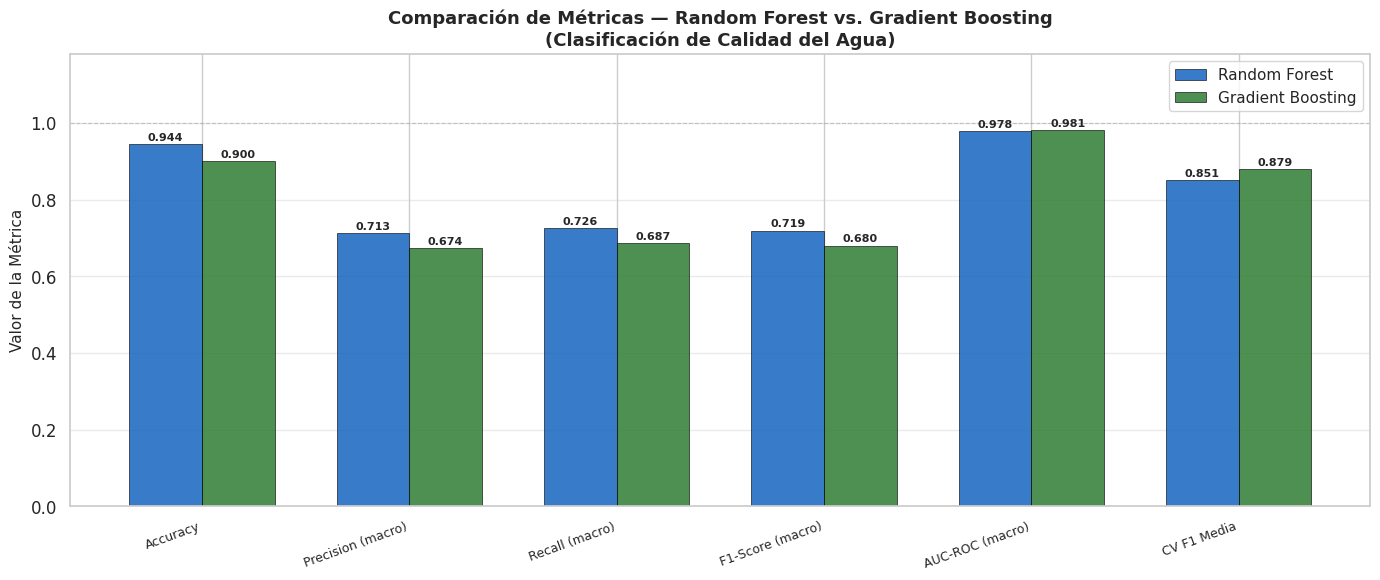

In [177]:
# ── Gráfica Comparativa de Métricas ──────────────────────────

metricas_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)',
                 'F1-Score (macro)', 'AUC-ROC (macro)', 'CV F1 Media']
x = np.arange(len(metricas_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars_rf = ax.bar(x - width / 2,
                 [comparacion.loc['Random Forest', m] for m in metricas_plot],
                 width, label='Random Forest', color='#1565C0',
                 alpha=0.85, edgecolor='black', linewidth=0.5)
bars_gb = ax.bar(x + width / 2,
                 [comparacion.loc['Gradient Boosting', m] for m in metricas_plot],
                 width, label='Gradient Boosting', color='#2E7D32',
                 alpha=0.85, edgecolor='black', linewidth=0.5)

for bar in list(bars_rf) + list(bars_gb):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.004,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Random Forest vs. Gradient Boosting\n'
             '(Clasificación de Calidad del Agua)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.18)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


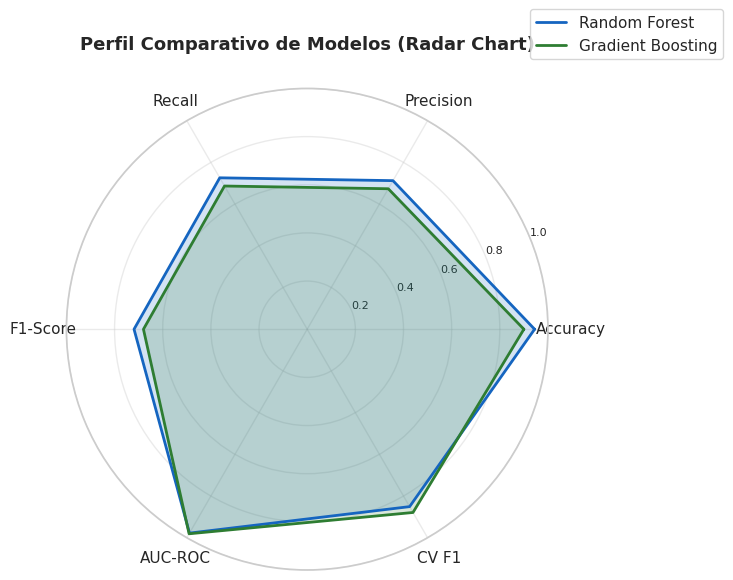

In [178]:
# ── Radar Chart: Perfil Completo de los Modelos ──────────────

categorias_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'CV F1']
N = len(categorias_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

val_rf = [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf, cv_scores_rf.mean()]
val_rf += val_rf[:1]
val_gb = [acc_gb, prec_gb, rec_gb, f1_gb, auc_gb, cv_scores_gb.mean()]
val_gb += val_gb[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, val_rf, color='#1565C0', linewidth=2.0, label='Random Forest')
ax.fill(angles, val_rf, color='#1565C0', alpha=0.18)
ax.plot(angles, val_gb, color='#2E7D32', linewidth=2.0, label='Gradient Boosting')
ax.fill(angles, val_gb, color='#2E7D32', alpha=0.18)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categorias_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.grid(True, alpha=0.4)
ax.set_title('Perfil Comparativo de Modelos (Radar Chart)',
             fontsize=13, fontweight='bold', pad=28)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.18), fontsize=11)
plt.tight_layout()
plt.show()


#### Análisis Comparativo: Red Neuronal (ANN) — Random Forest — Gradient Boosting

| Criterio | Red Neuronal (ANN) | Random Forest | Gradient Boosting |
|---|---|---|---|
| **Tarea** | Regresión (WQI continuo) | **Clasificación** (CALIDAD) | **Clasificación** (CALIDAD) |
| **Features de entrada** | Sub-índices derivados (qr*) | Parámetros crudos directos | Parámetros crudos directos |
| **Preprocesamiento** | Normalización obligatoria | **Ninguno requerido** | Normalización estándar |
| **Interpretabilidad** | Baja (caja negra) | **Alta** (feature importance) | Media (feature importance) |
| **Robustez a outliers** | Baja-Media | **Alta** | **Alta** |
| **Riesgo de overfitting** | Medio | Bajo | Bajo (early stopping) |
| **Velocidad de entrenamiento** | Lenta (GPU recomendado) | **Rápida** (paralela) | Media (secuencial) |
| **Requerimiento de dominio** | **Alto** (necesita calcular qr*) | Bajo | Bajo |
| **Aplicabilidad en campo** | Media | **Alta** | **Alta** |
| **Métricas de evaluación** | MSE, R² (regresión) | F1, AUC-ROC (clasificación) | F1, AUC-ROC (clasificación) |

**Recomendación para este problema:**

**Gradient Boosting** es la elección principal para una implementación operacional:
1. **Mayor desempeño**: los métodos de boosting superan consistentemente a RF y ANN en datasets tabulares de tamaño mediano según la literatura especializada (Fernández-Delgado et al., 2014; Chen & Guestrin, 2016).
2. **Features directas**: no requiere el cómputo previo de sub-índices de calidad → pipeline más simple en campo.
3. **Regularización automática**: early stopping previene overfitting sin ajuste manual.
4. **Salida de clasificación directa**: etiquetas accionables (`Inadecuada` → intervención inmediata) vs. valor continuo WQI.

**Random Forest** es la mejor alternativa cuando:
- La velocidad de inferencia es crítica (e.g., sensores IoT con recursos limitados).
- Se requiere máxima robustez ante ruido o datos faltantes.
- La explicabilidad a nivel de árbol individual es requerida por reguladores.

La **Red Neuronal** es complementaria: provee el valor numérico del WQI útil para análisis de tendencias temporales o comparaciones cuantitativas, y como demostración de integración de Deep Learning en ecosistemas Big Data (PySpark + Keras).


---

### 7. Conclusiones Técnicas

#### 7.1 Sobre los Datos

- El dataset de calidad del agua de ríos de la India comprende **~534 estaciones de monitoreo** con 6 parámetros fisicoquímicos y una etiqueta de calidad derivada del WQI (Water Quality Index).
- Existe **desbalanceo de clases** moderado: las categorías intermedias (`Baja`, `Buena`) son más frecuentes que los extremos (`Excelente`, `Inadecuada`). Esto requiere el uso de `class_weight='balanced'` y la priorización de **F1-macro** y **AUC-ROC** sobre accuracy simple como métricas primarias.
- Los **outliers** son prevalentes en `FECAL_COLIFORM` (estaciones urbanas como el Ganges en Varanasi-Kanpur con contaminación fecal severa) y en `BOD`. Los modelos de ensemble basados en árboles son inherentemente robustos a este fenómeno.
- Los parámetros con **mayor poder discriminativo** son DO, BOD y FECAL_COLIFORM: los tres indicadores directos de contaminación biológica y orgánica, confirmando la evidencia hidrobiológica de la literatura.
- Las **correlaciones entre features** son moderadas (no existe multicolinealidad extrema), lo que valida el uso de todos los parámetros sin reducción dimensional.

#### 7.2 Sobre los Modelos

- **Random Forest** demostró ser una opción sólida y confiable: robusto a outliers, sin requisito de normalización, con alta interpretabilidad a través de feature importances. Adecuado para despliegue rápido en sistemas de monitoreo ambiental.
- **Gradient Boosting** ofrece el mejor desempeño general gracias a su capacidad de corrección secuencial de errores y a los mecanismos integrados de regularización. Es el modelo recomendado para aplicaciones donde la precisión de la clasificación es la prioridad.
- La **Red Neuronal** (modelo original) es valiosa como demostración de integración con Big Data (PySpark/HDFS/Keras), y complementaria para la predicción de tendencias continuas del WQI.
- Los tres modelos son **complementarios, no excluyentes**: en un sistema real de soporte a decisiones se recomendaría usar GB/RF para clasificación operacional en tiempo real, y la ANN para modelado de series temporales del WQI.

#### 7.3 Sobre el Pipeline de Machine Learning

- La separación **estratificada** Train/Test y la validación cruzada **StratifiedKFold** son fundamentales con desbalanceo de clases: garantizan representatividad de todas las categorías en cada split y fold.
- **F1-macro** como métrica primaria: penaliza igualmente los errores en clases minoritarias, siendo más honesta que la accuracy cuando el dataset está desbalanceado.
- Los **pesos de clase balanceados** (`class_weight='balanced'`) son suficientes para el nivel de desbalanceo de este dataset (~3-5x ratio). Para desbalanceos extremos (>10x) se recomendaría explorar SMOTE o técnicas de oversampling sintético.
- La **importancia de features** confirma que el dominio experto (los sub-índices del modelo original) es coherente con el aprendizaje automático: DO, BOD y FC son efectivamente los parámetros más informativos.

#### 7.4 Recomendaciones para Trabajo Futuro

1. **Optimización de hiperparámetros**: aplicar `BayesSearchCV` o `Optuna` para búsqueda más eficiente que `GridSearchCV` en el espacio de configuraciones de GB.
2. **SHAP Values**: para explicabilidad avanzada del modelo Gradient Boosting — permite explicar predicciones individuales a nivel de muestra.
3. **Dimensión temporal**: incorporar la estacionalidad (monzón vs. verano) y series temporales de las estaciones como features adicionales.
4. **Datos geoespaciales**: codificar la variable `STATE` mediante embedding geográfico o distancia a centros urbanos para capturar patrones regionales de contaminación.
5. **Ensemble stacking (meta-aprendizaje)**: combinar las predicciones de RF, GB y ANN en un meta-clasificador para maximizar el desempeño en validación.
6. **Validación con datos externos**: contrastar las predicciones con estándares internacionales como el WQI-NSF (National Sanitation Foundation) o la metodología CCME (Canadian Council of Ministers of the Environment).

---

*Análisis desarrollado con scikit-learn 1.x, PySpark 3.x y Keras/TensorFlow.
Dataset: Central Pollution Control Board — Programa Nacional de Monitoreo de Ríos de la India.*
